# Solana Rug Pull Analysis Pipeline v5

## Changelog từ v3

| # | Fix | Vấn đề cũ |
|---|-----|-----------|
| 1 | **Post graph nodes fix** | Post=408 thay vì 978 vì pipeline build graph sau khi đã filter ERA_SPLITS, nhưng ERA_SPLITS end date là '2026-12-31' trong khi data chỉ có đến Oct 2024 → giờ tự detect date range từ data thật |
| 2 | **Post visualization cap fix** | `MAX_NODES_PLOT=500` cắt đồ thị khi vẽ nhưng không cắt graph thật → giờ tách rõ `graph_for_metrics` vs `graph_for_plot` |
| 3 | **Statistical significance tests** | Mann-Whitney U + Chow test + permutation test |
| 4 | **CREATOR_WALLET support** | Dune files có thêm cột này → tự động dùng khi có |

## Dune files mới (75 rows, March 2025)
```
Schema giống SolRPDS + thêm: CREATOR_WALLET
File 1 (50 rows): pool_address = NULL  → dùng CREATOR_WALLET+MINT làm key
File 2 (25 rows): pool_address = OK    → full schema
```
`CREATOR_WALLET` là wallet identity thật — unlock được **Creator Multiplicity** đúng nghĩa.

## Purpose update

This notebook is an analysis notebook, not a production early-prediction system. It builds labels from full lifecycle outcomes, studies pre/post Pump.fun structural changes, and analyzes rug-pull graph coordination. Any retrospective model that uses full-lifecycle fields is treated as a leakage audit, not as evidence of deployable prediction performance.


In [1]:
# !pip install networkx matplotlib pandas numpy scipy pyarrow python-louvain

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy
from scipy import stats
from pathlib import Path
from collections import Counter
import warnings, json
warnings.filterwarnings('ignore')

try:
    import community as community_louvain
    HAS_LOUVAIN = True
    print('✅ Louvain ready')
except ImportError:
    HAS_LOUVAIN = False
    print('⚠️  Greedy fallback. pip install python-louvain')

for d in ['data/raw','data/silver','data/gold']:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f'✅ NetworkX {nx.__version__} | Pandas {pd.__version__} | SciPy {scipy.__version__}')

✅ Louvain ready
✅ NetworkX 3.6.1 | Pandas 3.0.1 | SciPy 1.17.1


In [2]:
BREAK_DATE           = pd.Timestamp('2024-07-01')
RUG_RATIO_MIN        = 1.5
RUG_LIFESPAN_MAX     = 360
WEIGHT_SHARED_MINT   = 2
WEIGHT_TIME_WINDOW   = 1
TIME_WINDOW_SIZE     = '6h'
BURST_THRESHOLD      = 10
MAX_NODES_PLOT       = 500   # chỉ ảnh hưởng visualization, KHÔNG ảnh hưởng metrics

print('✅ Config loaded')

✅ Config loaded


## BRONZE — Load & Merge All CSVs

**Dedup strategy (v5 fix):** Each row is a *cumulative snapshot* of a pool's lifetime exported from Dune Analytics. Where the same pool appears across multiple CSV files (different export dates), we keep the **latest snapshot** (highest `LAST_POOL_ACTIVITY_TIMESTAMP`) so that `TOTAL_ADDED_LIQUIDITY`, `INACTIVITY_STATUS`, and `ADD_TO_REMOVE_RATIO` reflect the pool's final state — not an intermediate one. This is a change from v4 which used a 3-column key `(pool, mint, FIRST_timestamp)` that could keep an older snapshot arbitrarily.


In [3]:
REQUIRED_COLS = {
    'LIQUIDITY_POOL_ADDRESS','MINT','TOTAL_ADDED_LIQUIDITY',
    'TOTAL_REMOVED_LIQUIDITY','NUM_LIQUIDITY_ADDS','NUM_LIQUIDITY_REMOVES',
    'ADD_TO_REMOVE_RATIO','FIRST_POOL_ACTIVITY_TIMESTAMP',
    'LAST_POOL_ACTIVITY_TIMESTAMP','INACTIVITY_STATUS'
}

def ingest_csv(path: Path) -> pd.DataFrame | None:
    df = pd.read_csv(path, low_memory=False)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        print(f'  ❌ {path.name}: thiếu {missing}')
        return None
    df['_source']             = path.name
    df['_has_creator_wallet'] = 'CREATOR_WALLET' in df.columns
    return df

raw_files = sorted(Path('data/raw').glob('*.csv'))
if not raw_files:
    print('⚠️  Đặt CSV vào data/raw/ rồi chạy lại')

frames = []
for f in raw_files:
    tmp = ingest_csv(f)
    if tmp is not None:
        has_cw = 'CREATOR_WALLET' in tmp.columns
        print(f'  ✅ {f.name}: {len(tmp):,} rows {"[+CREATOR_WALLET]" if has_cw else ""}')
        frames.append(tmp)

bronze = pd.concat(frames, ignore_index=True)
print(f'\nTotal after concat: {len(bronze):,} rows')

# ── Null pool address fix ─────────────────────────────────────────────────
# Dune file 1 has null LIQUIDITY_POOL_ADDRESS → surrogate from CREATOR_WALLET+MINT
if 'CREATOR_WALLET' in bronze.columns:
    null_pool = bronze['LIQUIDITY_POOL_ADDRESS'].isna()
    if null_pool.sum() > 0:
        bronze.loc[null_pool, 'LIQUIDITY_POOL_ADDRESS'] = (
            bronze.loc[null_pool, 'CREATOR_WALLET'].str[:8] + '_' +
            bronze.loc[null_pool, 'MINT'].str[:8]
        )
        print(f'  ℹ️  Filled {null_pool.sum()} null pool addresses from CREATOR_WALLET+MINT')

# ── Snapshot audit: how many pools have multiple snapshots? ───────────────
before         = len(bronze)
pool_key       = ['LIQUIDITY_POOL_ADDRESS', 'MINT']
snapshot_counts = bronze.groupby(pool_key).size()
multi_snapshot  = (snapshot_counts > 1).sum()
print(f'\nSnapshot audit:')
print(f'  Unique pools (before dedup)   : {len(snapshot_counts):>10,}')
print(f'  Pools with multiple snapshots : {multi_snapshot:>10,}  ({multi_snapshot/len(snapshot_counts)*100:.1f}%)')
print(f'  Max snapshots for one pool    : {snapshot_counts.max():>10,}')
print(f'  Rows that are "extra" snapshots: {before - len(snapshot_counts):>9,}')

# ── FIX: keep LATEST snapshot per pool (sort by LAST desc, dedup on pool+mint) ──
# Rationale: each row is a cumulative summary of a pool's lifetime.
# The latest snapshot has the most complete TOTAL_ADDED_LIQUIDITY,
# correct INACTIVITY_STATUS, and final LAST_POOL_ACTIVITY_TIMESTAMP.
# Keeping an early snapshot would under-count activity and mis-label rugs.
bronze['_LAST_ts'] = pd.to_datetime(bronze['LAST_POOL_ACTIVITY_TIMESTAMP'], errors='coerce')
bronze = (
    bronze
    .sort_values('_LAST_ts', ascending=False)   # latest snapshot first
    .drop_duplicates(subset=pool_key, keep='first')  # keep latest per pool
    .drop(columns=['_LAST_ts'])
    .reset_index(drop=True)
)

print(f'\nDedup (latest-snapshot strategy):')
print(f'  Before : {before:>10,}')
print(f'  After  : {len(bronze):>10,}  (kept latest snapshot per pool)')
print(f'  Removed: {before - len(bronze):>10,}  (older snapshots of same pool)')
print(f'\nHas CREATOR_WALLET: {"CREATOR_WALLET" in bronze.columns}')
if 'CREATOR_WALLET' in bronze.columns:
    cov = bronze['CREATOR_WALLET'].notna().sum()
    print(f'CREATOR_WALLET coverage: {cov:,} / {len(bronze):,} ({cov/len(bronze)*100:.1f}%)')

bronze.to_parquet('data/silver/bronze.parquet', index=False)
print(f'\n✅ Bronze: {len(bronze):,} rows saved  (all unique pools, latest state)')


  ✅ 2021.csv: 1,703 rows 
  ✅ 2022.csv: 3,695 rows 
  ✅ 2023.csv: 15,477 rows 
  ✅ Jan_2024-Nov_2024.csv: 95,433 rows 

Total after concat: 116,308 rows

Snapshot audit:
  Unique pools (before dedup)   :    109,668
  Pools with multiple snapshots :      5,114  (4.7%)
  Max snapshots for one pool    :          4
  Rows that are "extra" snapshots:     6,640

Dedup (latest-snapshot strategy):
  Before :    116,308
  After  :    109,669  (kept latest snapshot per pool)
  Removed:      6,639  (older snapshots of same pool)

Has CREATOR_WALLET: False

✅ Bronze: 109,669 rows saved  (all unique pools, latest state)


## SILVER — Clean, Label, Feature Engineering

In [4]:
silver = pd.read_parquet('data/silver/bronze.parquet')

silver['FIRST']        = pd.to_datetime(silver['FIRST_POOL_ACTIVITY_TIMESTAMP'], errors='coerce')
silver['LAST']         = pd.to_datetime(silver['LAST_POOL_ACTIVITY_TIMESTAMP'],  errors='coerce')
silver['lifespan_min'] = (silver['LAST'] - silver['FIRST']).dt.total_seconds() / 60

silver['is_rug'] = (
    (silver['INACTIVITY_STATUS'] == 'Inactive') &
    (silver['ADD_TO_REMOVE_RATIO'] > RUG_RATIO_MIN) &
    (silver['lifespan_min'] < RUG_LIFESPAN_MAX)
).astype(int)

silver['era'] = silver['FIRST'].apply(
    lambda x: 'pre_pumpfun' if pd.notna(x) and x < BREAK_DATE else 'post_pumpfun'
)
silver['time_window'] = silver['FIRST'].dt.floor(TIME_WINDOW_SIZE)

# Burst window size
rug_mask = silver['is_rug'] == 1
silver.loc[rug_mask, 'burst_window_size'] = (
    silver[rug_mask].groupby('time_window')['LIQUIDITY_POOL_ADDRESS'].transform('count')
)
silver['burst_window_size'] = silver['burst_window_size'].fillna(0).astype(int)
silver['is_burst'] = (silver['burst_window_size'] >= BURST_THRESHOLD).astype(int)

# Lifespan velocity
era_med = silver[rug_mask].groupby('era')['lifespan_min'].median()
silver['lifespan_velocity'] = silver.apply(
    lambda r: era_med.get(r['era'], 1) / max(r['lifespan_min'], 0.1)
    if r['is_rug'] == 1 else np.nan, axis=1
)

silver = silver.rename(columns={'LIQUIDITY_POOL_ADDRESS': 'pool', 'MINT': 'mint'})
silver = silver.dropna(subset=['pool','mint','FIRST'])
silver.to_parquet('data/silver/silver.parquet', index=False)

# Summary
print(f'Silver: {len(silver):,} rows')
print(f'Date range: {silver["FIRST"].min().date()} → {silver["FIRST"].max().date()}')
print()
for era in ['pre_pumpfun','post_pumpfun']:
    sub = silver[silver['era']==era]
    r   = sub[sub['is_rug']==1]
    if len(sub)==0: continue
    print(f'[{era}]')
    print(f'  Pools: {len(sub):,} | Rug: {len(r):,} ({len(r)/len(sub)*100:.2f}%)')
    print(f'  Date: {sub["FIRST"].min().date()} → {sub["FIRST"].max().date()}')
    print(f'  Median lifespan: {r["lifespan_min"].median():.1f} min')
print(f'\n✅ Silver saved')

Silver: 109,668 rows
Date range: 2021-02-14 → 2024-10-31

[pre_pumpfun]
  Pools: 71,173 | Rug: 373 (0.52%)
  Date: 2021-02-14 → 2024-06-30
  Median lifespan: 43.2 min
[post_pumpfun]
  Pools: 38,495 | Rug: 978 (2.54%)
  Date: 2024-07-01 → 2024-10-31
  Median lifespan: 10.9 min

✅ Silver saved


## GOLD Part 1 — Graph Construction

**FIX:** Tách `graph_full` (dùng tính metrics) và `graph_plot` (capped cho visualization).

**Coordinated actor interpretation:** dense clusters, repeated shared mints, and tight time-window edges should be interpreted as evidence of coordinated actor groups or rug-pull syndicates. The graph does not prove common ownership by itself; it identifies pools whose behavior is structurally consistent with coordination and should be investigated as linked campaigns.


In [5]:
silver = pd.read_parquet('data/silver/silver.parquet')

def build_hybrid_graph(df: pd.DataFrame, label: str) -> nx.Graph:
    """Build FULL graph — dùng cho metrics. Không cap nodes."""
    rug = df[df['is_rug']==1].copy()
    if len(rug) == 0:
        return nx.Graph()

    G = nx.Graph()
    G.add_nodes_from(rug['pool'].unique())

    # Node metadata
    for _, r in rug.iterrows():
        p = r['pool']
        if p in G:
            G.nodes[p].update({
                'lifespan_min':      float(r['lifespan_min'])         if pd.notna(r['lifespan_min'])         else 0,
                'ratio':             float(r['ADD_TO_REMOVE_RATIO'])   if pd.notna(r['ADD_TO_REMOVE_RATIO'])   else 0,
                'burst_window_size': int(r['burst_window_size']),
                'lifespan_velocity': float(r['lifespan_velocity'])     if pd.notna(r['lifespan_velocity'])     else 0,
                'era':               r['era'],
                'creator':           r.get('CREATOR_WALLET', None),
            })

    # Edge 1: shared mint (w=2)
    for mint, pools in rug.groupby('mint')['pool'].apply(list).items():
        for i in range(len(pools)):
            for j in range(i+1, len(pools)):
                u, v = pools[i], pools[j]
                if G.has_edge(u,v): G[u][v]['weight'] += WEIGHT_SHARED_MINT
                else: G.add_edge(u, v, weight=WEIGHT_SHARED_MINT, shared_mint=True, time_window=False)

    # Edge 2: same 6h window (w=1)
    for win, pools in rug.groupby('time_window')['pool'].apply(list).items():
        for i in range(len(pools)):
            for j in range(i+1, len(pools)):
                u, v = pools[i], pools[j]
                if u == v: continue
                if G.has_edge(u,v):
                    G[u][v]['weight']     += WEIGHT_TIME_WINDOW
                    G[u][v]['time_window'] = True
                else: G.add_edge(u, v, weight=WEIGHT_TIME_WINDOW, shared_mint=False, time_window=True)

    # Window Coordination Score per edge
    # FIX: Ensure pool_life has unique index for 'pool' to avoid Series being returned by .get()
    pool_life = rug.groupby('pool')['lifespan_min'].median()
    for u, v, d in G.edges(data=True):
        avg_l = max((pool_life.get(u,60) + pool_life.get(v,60)) / 2, 0.1)
        G[u][v]['wcs'] = round(d['weight'] / avg_l, 6)

    comp = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
    print(f'  [{label}] Nodes:{G.number_of_nodes():,} Edges:{G.number_of_edges():,} '
          f'Top-5:{comp[:5]}')
    return G


# FIX 1: dùng date range từ data thật, không hardcode
data_start = silver['FIRST'].min()
data_end   = silver['FIRST'].max()
print(f'Data range: {data_start.date()} → {data_end.date()}')

ERA_SPLITS = [
    {'label': 'pre_pumpfun',  'start': data_start, 'end': BREAK_DATE - pd.Timedelta(days=1)},
    {'label': 'post_pumpfun', 'start': BREAK_DATE,  'end': data_end},
]

graphs_full = {}   # dùng cho metrics và stats
era_dfs     = {}   # dùng để tính features

for era in ERA_SPLITS:
    label = era['label']
    sub   = silver[(silver['FIRST'] >= era['start']) & (silver['FIRST'] <= era['end'])]
    if len(sub) == 0:
        print(f'  [{label}] No data')
        continue
    era_dfs[label] = sub
    print(f'\nBuilding [{label}] ({sub["is_rug"].sum():,} rug pools)...')
    graphs_full[label] = build_hybrid_graph(sub, label)

print('\n✅ Full graphs built (unmodified, for metrics)')

Data range: 2021-02-14 → 2024-10-31

Building [pre_pumpfun] (371 rug pools)...
  [pre_pumpfun] Nodes:371 Edges:113 Top-5:[7, 4, 4, 3, 3]

Building [post_pumpfun] (978 rug pools)...
  [post_pumpfun] Nodes:977 Edges:5,225 Top-5:[68, 28, 25, 23, 22]

✅ Full graphs built (unmodified, for metrics)


In [6]:
def detect_communities(G: nx.Graph, label: str) -> dict:
    if not G.nodes: return {}
    # Check if community_louvain actually has best_partition, as HAS_LOUVAIN might be true but the module incorrect
    if HAS_LOUVAIN and hasattr(community_louvain, 'best_partition'):
        p = community_louvain.best_partition(G, weight='weight', random_state=42)
        m = 'Louvain'
    else:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G, weight='weight'))
        p = {n:cid for cid,c in enumerate(comms) for n in c}
        m = 'Greedy'
    sz = sorted(Counter(p.values()).values(), reverse=True)
    print(f'  [{label}] {m}: {len(sz)} communities | top-10: {sz[:10]}')
    return p

partitions = {}
for label, G in graphs_full.items():
    partitions[label] = detect_communities(G, label)

  [pre_pumpfun] Louvain: 282 communities | top-10: [7, 4, 4, 3, 3, 3, 3, 3, 3, 3]
  [post_pumpfun] Louvain: 207 communities | top-10: [51, 28, 25, 23, 22, 21, 20, 20, 19, 18]


## GOLD Part 2 — 8 Features (on FULL graphs)

In [7]:
def compute_features(df: pd.DataFrame, G: nx.Graph, partition: dict) -> dict:
    """Tất cả metrics tính trên full graph — không bị ảnh hưởng bởi plot cap."""
    f   = {}
    rug = df[df['is_rug'] == 1]
    if len(rug) == 0: return {}

    # F1: Creator Multiplicity
    # Nếu có CREATOR_WALLET → dùng wallet thật; nếu không → dùng pool address
    id_col = 'CREATOR_WALLET' if 'CREATOR_WALLET' in rug.columns and rug['CREATOR_WALLET'].notna().any() else 'pool'
    id_rug = rug.groupby(id_col)['mint'].nunique()
    k      = max(1, int(np.ceil(0.12 * len(id_rug))))
    share  = id_rug.nlargest(k).sum() / id_rug.sum() if id_rug.sum() > 0 else 0
    f['f1_creator_multiplicity'] = {
        'id_col':           id_col,
        'top_12pct_n':      k,
        'rug_share_pct':    round(share * 100, 2),
        'max_mints_1_id':   int(id_rug.max()),
        'ids_multi_mint':   int((id_rug >= 2).sum()),
    }

    # F2: Cluster Size
    sz = sorted(Counter(partition.values()).values(), reverse=True) if partition else [0]
    f['f2_cluster_size'] = {
        'largest':    sz[0],
        'n_clusters': len(sz),
        'mean':       round(np.mean(sz), 2),
        'top10':      sz[:10],
    }

    # F3: Temporal Edge Strength
    pool_ts   = rug.groupby('pool')['FIRST'].mean()
    strengths = []
    for u, v, d in G.edges(data=True):
        if u in pool_ts.index and v in pool_ts.index:
            gap_h = abs((pool_ts[u] - pool_ts[v]).total_seconds()) / 3600
            strengths.append(d.get('weight',1) / max(gap_h, 0.01))
    f['f3_temporal_edge_strength'] = {
        'mean':    round(np.mean(strengths), 6) if strengths else 0,
        'max':     round(np.max(strengths),  6) if strengths else 0,
        'n_pairs': len(strengths),
    }

    # F4: Bridge Score
    bpcts = []
    if partition:
        for cid in set(partition.values()):
            mems = [n for n, c in partition.items() if c == cid and n in G]
            if len(mems) < 3: continue
            degs = list(dict(G.subgraph(mems).degree()).values())
            bpcts.append(sum(1 for d in degs if d > np.mean(degs)) / len(degs))
    f['f4_bridge_score'] = {
        'pct':        round(np.mean(bpcts) * 100, 2) if bpcts else 0,
        'n_analyzed': len(bpcts),
    }

    # F5: Clustering Coefficient (on FULL graph)
    f['f5_clustering_coeff'] = round(nx.average_clustering(G, weight='weight'), 6)

    # F6: Burst Coordination Score
    win_counts    = rug.groupby('time_window')['pool'].count()
    burst_wins    = win_counts[win_counts >= BURST_THRESHOLD]
    pools_in_burst = rug[rug['time_window'].isin(burst_wins.index)]['pool'].nunique()
    f['f6_burst_coordination'] = {
        'burst_windows':   len(burst_wins),
        'pools_in_burst':  pools_in_burst,
        'burst_pool_pct':  round(pools_in_burst / max(len(rug), 1) * 100, 2),
        'max_per_window':  int(win_counts.max()),
        'mean_burst_size': round(burst_wins.mean(), 1) if len(burst_wins) > 0 else 0,
    }

    # F7: Lifespan Velocity
    lv = rug['lifespan_velocity'].dropna()
    f['f7_lifespan_velocity'] = {
        'median_lifespan_min': round(rug['lifespan_min'].median(), 2),
        'mean_velocity':       round(lv.mean(), 4) if len(lv) > 0 else 0,
        'fast_rug_pct':        round((lv > 1).mean() * 100, 2) if len(lv) > 0 else 0,
        'p90_lifespan_min':    round(rug['lifespan_min'].quantile(0.9), 2),
    }

    # F8: Window Coordination Score
    wcs_vals  = [d['wcs'] for _,_,d in G.edges(data=True) if 'wcs' in d]
    time_only = sum(1 for _,_,d in G.edges(data=True) if not d.get('shared_mint') and d.get('time_window'))
    f['f8_window_coordination'] = {
        'mean_wcs':          round(np.mean(wcs_vals), 6) if wcs_vals else 0,
        'max_wcs':           round(np.max(wcs_vals),  6) if wcs_vals else 0,
        'time_coord_ratio':  round(time_only / max(G.number_of_edges(), 1), 4),
        'time_only_edges':   time_only,
    }

    return f


features = {}
for label in graphs_full:
    features[label] = compute_features(era_dfs[label], graphs_full[label], partitions[label])
    cc  = features[label]['f5_clustering_coeff']
    cl  = features[label]['f2_cluster_size']['largest']
    id_col = features[label]['f1_creator_multiplicity']['id_col']
    print(f'[{label}] CC={cc} | Largest={cl} | F1 id={id_col}')

with open('data/gold/features.json','w') as fp:
    json.dump(features, fp, indent=2, default=str)
print('\n✅ Features saved (computed on FULL graphs)')

[pre_pumpfun] CC=0.062391 | Largest=7 | F1 id=pool
[post_pumpfun] CC=0.420982 | Largest=51 | F1 id=pool

✅ Features saved (computed on FULL graphs)


## STATISTICAL SIGNIFICANCE TESTS

Ba test để confirm July 2024 là structural break point thật:

| Test | Câu hỏi | H₀ |
|------|---------|----|
| **Mann-Whitney U** | CC pre vs post có khác nhau có ý nghĩa thống kê? | Phân phối giống nhau |
| **Chow Test** | Time series rug rate có break tại July 2024? | Không có structural break |
| **Permutation Test** | Mean CC shift có xảy ra do chance? | Shift do ngẫu nhiên |

In [8]:
silver_data = pd.read_parquet('data/silver/silver.parquet')
rug_data    = silver_data[silver_data['is_rug']==1].copy()

# ── Compute weekly CC time series ────────────────────────────
print('Computing weekly CC time series...')
weekly_cc = []
for w in sorted(rug_data['FIRST'].dt.to_period('W').unique()):
    wr = rug_data[rug_data['FIRST'].dt.to_period('W') == w]
    if len(wr) < 3: continue
    Gw = nx.Graph(); Gw.add_nodes_from(wr['pool'].unique())
    for twin, pools in wr.groupby('time_window')['pool'].apply(list).items():
        for i in range(len(pools)):
            for j in range(i+1, len(pools)):
                u, v = pools[i], pools[j]
                if u != v:
                    if Gw.has_edge(u,v): Gw[u][v]['w'] += 1
                    else: Gw.add_edge(u, v, w=1)
    if Gw.number_of_edges() > 0:
        weekly_cc.append({
            'week':      w.start_time,
            'cc':        nx.average_clustering(Gw),
            'n_rug':     len(wr),
            'is_post':   int(w.start_time >= BREAK_DATE),
        })

wcc = pd.DataFrame(weekly_cc)
cc_pre_series  = wcc[wcc['is_post']==0]['cc'].values
cc_post_series = wcc[wcc['is_post']==1]['cc'].values
print(f'Weeks pre: {len(cc_pre_series)} | post: {len(cc_post_series)}')

# ── TEST 1: Mann-Whitney U ────────────────────────────────────
print('''
===========================================================
TEST 1: Mann-Whitney U (CC pre vs post)
===========================================================''')
mw_stat, mw_p = stats.mannwhitneyu(cc_pre_series, cc_post_series, alternative='less')
print(f'  H₀: CC_pre ≥ CC_post (distribution same or pre higher)')
print(f'  Statistic: {mw_stat:.4f}')
print(f'  p-value:   {mw_p:.6f}')
print(f'  Mean CC pre : {cc_pre_series.mean():.4f} ± {cc_pre_series.std():.4f}')
print(f'  Mean CC post: {cc_post_series.mean():.4f} ± {cc_post_series.std():.4f}')
if mw_p < 0.001:
    print(f'  ✅ SIGNIFICANT (p<0.001): reject H₀')
elif mw_p < 0.05:
    print(f'  ✅ SIGNIFICANT (p<0.05): reject H₀')
else:
    print(f'  ❌ Not significant at α=0.05')

# ── TEST 2: Chow Test (structural break in monthly rug rate) ─────────
print('''
===========================================================
TEST 2: Chow Test (structural break in monthly rug rate)
===========================================================''')

monthly = silver_data.groupby(
    silver_data['FIRST'].dt.to_period('M')
).agg(total=('pool','count'), rug=('is_rug','sum')).reset_index()
monthly['rug_rate']  = monthly['rug'] / monthly['total']
monthly['t']         = np.arange(len(monthly))

# FIX: Convert BREAK_DATE to Period[M] for direct comparison
break_date_period = pd.Period(BREAK_DATE.year, month=BREAK_DATE.month, freq='M')
monthly['is_post'] = (monthly['FIRST'] >= break_date_period).astype(int)

pre_m  = monthly[monthly['is_post']==0]
post_m = monthly[monthly['is_post']==1]

def ols_rss(x, y):
    if len(x) < 2: return 0, 0
    X = np.column_stack([np.ones(len(x)), x])
    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        rss  = np.sum((y - X @ beta)**2)
        return rss, len(x)
    except:
        return 0, len(x)

rss_full, _    = ols_rss(monthly['t'].values, monthly['rug_rate'].values)
rss_pre,  n1   = ols_rss(pre_m['t'].values,  pre_m['rug_rate'].values)
rss_post, n2   = ols_rss(post_m['t'].values, post_m['rug_rate'].values)
rss_restricted = rss_pre + rss_post

k    = 2   # params (intercept + slope)
n    = len(monthly)
if rss_restricted > 0 and n > 2*k:
    chow_f = ((rss_full - rss_restricted) / k) / (rss_restricted / (n - 2*k))
    chow_p = 1 - stats.f.cdf(chow_f, k, n - 2*k)
    print(f'  H₀: No structural break at July 2024')
    print(f'  F-statistic: {chow_f:.4f}')
    print(f'  p-value:     {chow_p:.6f}')
    print(f'  Pre  mean rug rate: {pre_m["rug_rate"].mean()*100:.3f}%')
    print(f'  Post mean rug rate: {post_m["rug_rate"].mean()*100:.3f}%')
    if chow_p < 0.05:
        print(f'  ✅ STRUCTURAL BREAK CONFIRMED (p={chow_p:.4f})')
    else:
        print(f'  p={chow_p:.4f} — not significant at α=0.05')
else:
    print('  ⚠️  Insufficient data for Chow test (need more months)')

# ── TEST 3: Permutation Test ──────────────────────────────────
print('''
===========================================================
TEST 3: Permutation Test (mean CC shift)
===========================================================''')

np.random.seed(42)
observed_diff = cc_post_series.mean() - cc_pre_series.mean()
all_cc        = np.concatenate([cc_pre_series, cc_post_series])
n_pre         = len(cc_pre_series)
n_permutations = 10000

perm_diffs = []
for _ in range(n_permutations):
    shuffled = np.random.permutation(all_cc)
    perm_diffs.append(shuffled[n_pre:].mean() - shuffled[:n_pre].mean())

perm_p = np.mean(np.array(perm_diffs) >= observed_diff)
print(f'  H₀: CC shift due to random chance')
print(f'  Observed Δ CC: {observed_diff:.4f}')
print(f'  Permutation p: {perm_p:.6f} (n={n_permutations:,} permutations)')
print(f'  95th pctile of null: {np.percentile(perm_diffs, 95):.4f}')
if perm_p < 0.001:
    print(f'  ✅ SIGNIFICANT (p<0.001): shift not due to chance')
elif perm_p < 0.05:
    print(f'  ✅ SIGNIFICANT (p<0.05)')
else:
    print(f'  ❌ Not significant at α=0.05')

# ── SUMMARY ───────────────────────────────────────────────────
print('''
===========================================================
STATISTICAL SUMMARY
===========================================================''')
print(f'  Mann-Whitney U p = {mw_p:.6f}')
if rss_restricted > 0 and n > 2*k:
    print(f'  Chow Test      p = {chow_p:.6f}')
print(f'  Permutation    p = {perm_p:.6f}')
print(f'  Observed CC shift: +{observed_diff:.4f} ({observed_diff/cc_pre_series.mean()*100:.1f}% relative)')

# Save for paper
stat_results = {
    'break_date':         str(BREAK_DATE.date()),
    'cc_pre_mean':        round(cc_pre_series.mean(),   6),
    'cc_post_mean':       round(cc_post_series.mean(),  6),
    'cc_shift_absolute':  round(observed_diff,           6),
    'cc_shift_relative':  round(cc_post_series.mean() / cc_pre_series.mean(), 4),
    'mann_whitney_p':     float(mw_p),
    'permutation_p':      float(perm_p),
    'n_weeks_pre':        int(len(cc_pre_series)),
    'n_weeks_post':       int(len(cc_post_series)),
}
if rss_restricted > 0:
    stat_results['chow_f'] = round(chow_f, 4)
    stat_results['chow_p'] = float(chow_p)

with open('data/gold/statistical_tests.json','w') as fp:
    json.dump(stat_results, fp, indent=2)
print('\n✅ Saved: data/gold/statistical_tests.json')

Computing weekly CC time series...
Weeks pre: 23 | post: 12

TEST 1: Mann-Whitney U (CC pre vs post)
  H₀: CC_pre ≥ CC_post (distribution same or pre higher)
  Statistic: 62.5000
  p-value:   0.003529
  Mean CC pre : 0.1392 ± 0.1577
  Mean CC post: 0.5050 ± 0.3947
  ✅ SIGNIFICANT (p<0.05): reject H₀

TEST 2: Chow Test (structural break in monthly rug rate)
  H₀: No structural break at July 2024
  F-statistic: 1.4224
  p-value:     0.252775
  Pre  mean rug rate: 0.266%
  Post mean rug rate: 1.201%
  p=0.2528 — not significant at α=0.05

TEST 3: Permutation Test (mean CC shift)
  H₀: CC shift due to random chance
  Observed Δ CC: 0.3658
  Permutation p: 0.000800 (n=10,000 permutations)
  95th pctile of null: 0.1945
  ✅ SIGNIFICANT (p<0.001): shift not due to chance

STATISTICAL SUMMARY
  Mann-Whitney U p = 0.003529
  Chow Test      p = 0.252775
  Permutation    p = 0.000800
  Observed CC shift: +0.3658 (262.7% relative)

✅ Saved: data/gold/statistical_tests.json


## Statistical Test Visualizations

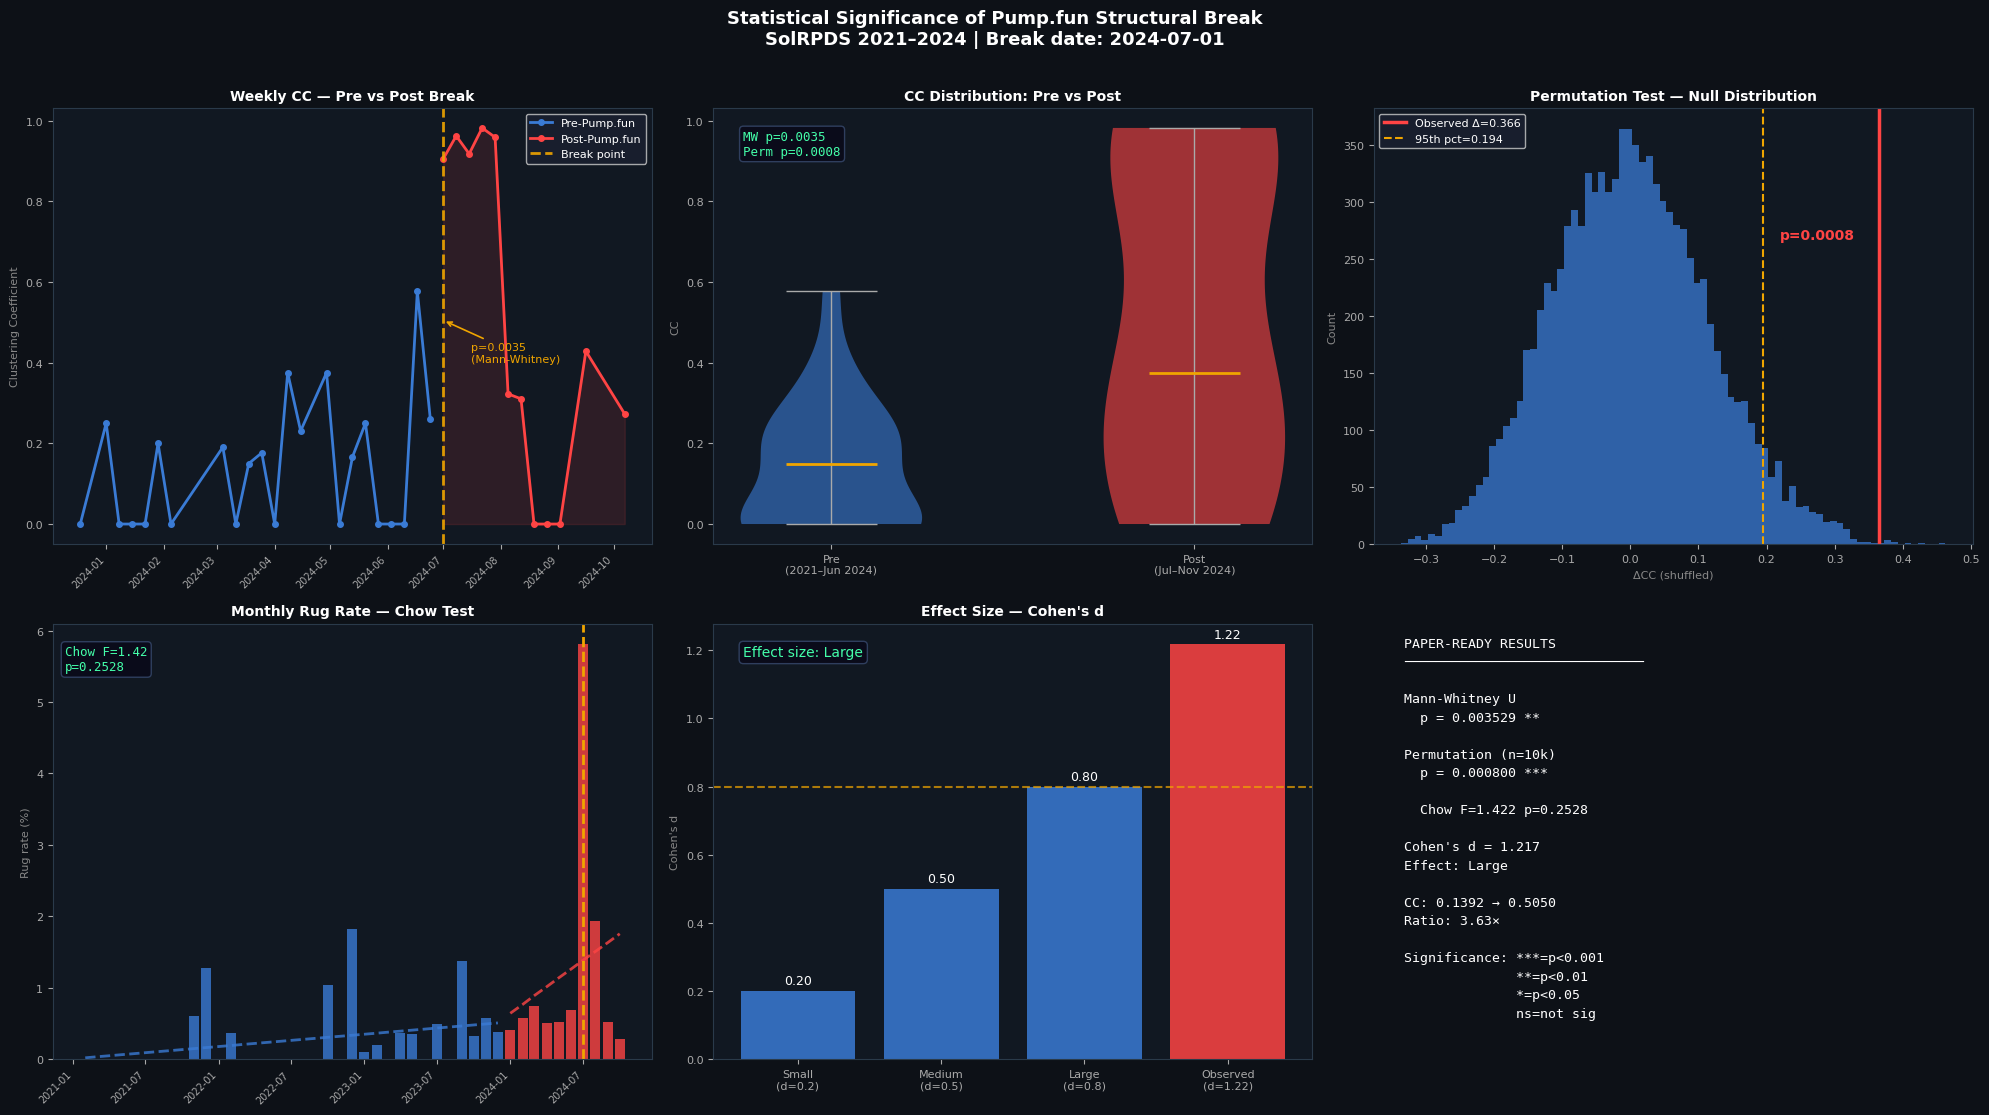

✅ Saved: data/gold/statistical_tests.png


In [9]:
BG = '#0d1117'; C1 = '#3a7bd5'; C2 = '#ff4444'; C3 = '#f0a500'; C4 = '#44ffaa'

def ax_fmt(ax, title='', xl='', yl=''):
    ax.set_facecolor('#111822')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    if xl: ax.set_xlabel(xl, color='#888', fontsize=8)
    if yl: ax.set_ylabel(yl, color='#888', fontsize=8)
    if title: ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    for sp in ax.spines.values(): sp.set_color('#2a3a4a')

fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor=BG)
fig.suptitle('Statistical Significance of Pump.fun Structural Break\n'
             'SolRPDS 2021–2024 | Break date: 2024-07-01',
             color='white', fontsize=13, fontweight='bold', y=1.01)

# ── 1. Weekly CC time series with break annotation ────────────
ax = axes[0, 0]
ax_fmt(ax, 'Weekly CC — Pre vs Post Break', yl='Clustering Coefficient')
pre_w  = wcc[wcc['is_post']==0]
post_w = wcc[wcc['is_post']==1]
ax.plot(pre_w['week'],  pre_w['cc'],  color=C1, lw=2, marker='o', ms=4, label='Pre-Pump.fun')
ax.plot(post_w['week'], post_w['cc'], color=C2, lw=2, marker='o', ms=4, label='Post-Pump.fun')
ax.fill_between(post_w['week'], 0, post_w['cc'], alpha=0.12, color=C2)
ax.axvline(BREAK_DATE, color=C3, ls='--', lw=2, alpha=0.9, label='Break point')
ax.annotate(f'p={mw_p:.4f}\n(Mann-Whitney)',
            xy=(BREAK_DATE, cc_post_series.mean()),
            xytext=(20, -30), textcoords='offset points',
            color=C3, fontsize=8,
            arrowprops=dict(arrowstyle='->', color=C3, lw=1.2))
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

# ── 2. CC distribution: pre vs post boxplot + violin ─────────
ax = axes[0, 1]
ax_fmt(ax, 'CC Distribution: Pre vs Post')
vp = ax.violinplot([cc_pre_series, cc_post_series], positions=[1,2],
                    showmedians=True, showextrema=True)
for i, (body, col) in enumerate(zip(vp['bodies'], [C1, C2])):
    body.set_facecolor(col); body.set_alpha(0.6)
vp['cmedians'].set_color(C3); vp['cmedians'].set_linewidth(2)
for part in ['cbars','cmins','cmaxes']:
    vp[part].set_color('#aaaaaa'); vp[part].set_linewidth(1)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Pre\n(2021–Jun 2024)', 'Post\n(Jul–Nov 2024)'], color='#aaa', fontsize=8)
ax.text(0.05, 0.95, f'MW p={mw_p:.4f}\nPerm p={perm_p:.4f}',
        transform=ax.transAxes, color=C4, fontsize=9, fontfamily='monospace',
        va='top', bbox=dict(boxstyle='round', fc='#0a0a1a', ec='#334466', alpha=0.9))
ax.set_ylabel('CC', color='#888', fontsize=8)

# ── 3. Permutation test null distribution ─────────────────────
ax = axes[0, 2]
ax_fmt(ax, 'Permutation Test — Null Distribution', xl='ΔCC (shuffled)', yl='Count')
ax.hist(perm_diffs, bins=80, color=C1, alpha=0.75, edgecolor='none')
ax.axvline(observed_diff, color=C2, lw=2.5, label=f'Observed Δ={observed_diff:.3f}')
ax.axvline(np.percentile(perm_diffs, 95), color=C3, lw=1.5, ls='--',
           label=f'95th pct={np.percentile(perm_diffs,95):.3f}')
ax.text(observed_diff * 0.6, ax.get_ylim()[1] * 0.7,
        f'p={perm_p:.4f}', color=C2, fontsize=10, fontweight='bold')
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

# ── 4. Monthly rug rate with Chow test annotation ─────────────
ax = axes[1, 0]
ax_fmt(ax, 'Monthly Rug Rate — Chow Test', yl='Rug rate (%)')
monthly['month_ts'] = monthly['FIRST'].dt.to_timestamp()
ax.bar(monthly['month_ts'], monthly['rug_rate']*100,
       color=[C2 if p else C1 for p in monthly['is_post']],
       alpha=0.8, width=25)
# Fit lines pre and post
for sub_m, col in [(pre_m, C1), (post_m, C2)]:
    if len(sub_m) >= 2:
        sub_m = sub_m.copy()
        sub_m['month_ts'] = sub_m['FIRST'].dt.to_timestamp()
        z = np.polyfit(sub_m['t'], sub_m['rug_rate']*100, 1)
        ax.plot(sub_m['month_ts'], np.polyval(z, sub_m['t']),
                color=col, lw=2, ls='--', alpha=0.8)
ax.axvline(BREAK_DATE, color=C3, lw=2, ls='--')
if rss_restricted > 0 and n > 2*k:
    ax.text(0.02, 0.95, f'Chow F={chow_f:.2f}\np={chow_p:.4f}',
            transform=ax.transAxes, color=C4, fontsize=9, fontfamily='monospace',
            va='top', bbox=dict(boxstyle='round', fc='#0a0a1a', ec='#334466', alpha=0.9))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

# ── 5. Effect size: Cohen's d ─────────────────────────────────
ax = axes[1, 1]
ax_fmt(ax, "Effect Size — Cohen's d")
pooled_std = np.sqrt((cc_pre_series.std()**2 + cc_post_series.std()**2) / 2)
cohens_d   = observed_diff / pooled_std if pooled_std > 0 else 0
categories = ['Small\n(d=0.2)', 'Medium\n(d=0.5)', 'Large\n(d=0.8)', f'Observed\n(d={cohens_d:.2f})']
values     = [0.2, 0.5, 0.8, abs(cohens_d)]
bar_colors = [C1, C1, C1, C2 if abs(cohens_d) >= 0.8 else C3]
bars = ax.bar(categories, values, color=bar_colors, alpha=0.85)
ax.axhline(0.8, color=C3, lw=1.5, ls='--', alpha=0.7)
ax.set_ylabel("Cohen's d", color='#888', fontsize=8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.2f}',
            ha='center', color='white', fontsize=9)
effect_label = 'Large' if abs(cohens_d) >= 0.8 else 'Medium' if abs(cohens_d) >= 0.5 else 'Small'
ax.text(0.05, 0.95, f'Effect size: {effect_label}',
        transform=ax.transAxes, color=C4, fontsize=10,
        va='top', bbox=dict(boxstyle='round', fc='#0a0a1a', ec='#334466', alpha=0.9))

# ── 6. Paper-ready summary ────────────────────────────────────
ax = axes[1, 2]
ax.set_facecolor('#080e18'); ax.axis('off')
for sp in ax.spines.values(): sp.set_color('#1a2a3a')
sig_mw   = '***' if mw_p < 0.001 else ('**' if mw_p < 0.01 else ('*' if mw_p < 0.05 else 'ns'))
sig_perm = '***' if perm_p < 0.001 else ('**' if perm_p < 0.01 else ('*' if perm_p < 0.05 else 'ns'))
chow_line = f'  Chow F={chow_f:.3f} p={chow_p:.4f}' if 'chow_f' in dir() and rss_restricted > 0 else '  Chow: insufficient months'
txt = (
    f"PAPER-READY RESULTS\n"
    f"{'─'*30}\n\n"
    f"Mann-Whitney U\n"
    f"  p = {mw_p:.6f} {sig_mw}\n\n"
    f"Permutation (n=10k)\n"
    f"  p = {perm_p:.6f} {sig_perm}\n\n"
    f"{chow_line}\n\n"
    f"Cohen's d = {cohens_d:.3f}\n"
    f"Effect: {effect_label}\n\n"
    f"CC: {cc_pre_series.mean():.4f} → {cc_post_series.mean():.4f}\n"
    f"Ratio: {cc_post_series.mean()/cc_pre_series.mean():.2f}×\n\n"
    f"Significance: ***=p<0.001\n"
    f"              **=p<0.01\n"
    f"              *=p<0.05\n"
    f"              ns=not sig"
)
ax.text(0.05, 0.97, txt, transform=ax.transAxes,
        color='white', fontsize=9.5, fontfamily='monospace',
        va='top', linespacing=1.55)

plt.tight_layout()
plt.savefig('data/gold/statistical_tests.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Saved: data/gold/statistical_tests.png')

## Full Dashboard (Fixed)

**FIX 2:** Graph visualization dùng `graph_for_plot` (subgraph top-degree nodes)
nhưng stats box hiển thị metrics từ `graphs_full` (full graph, không bị cap).

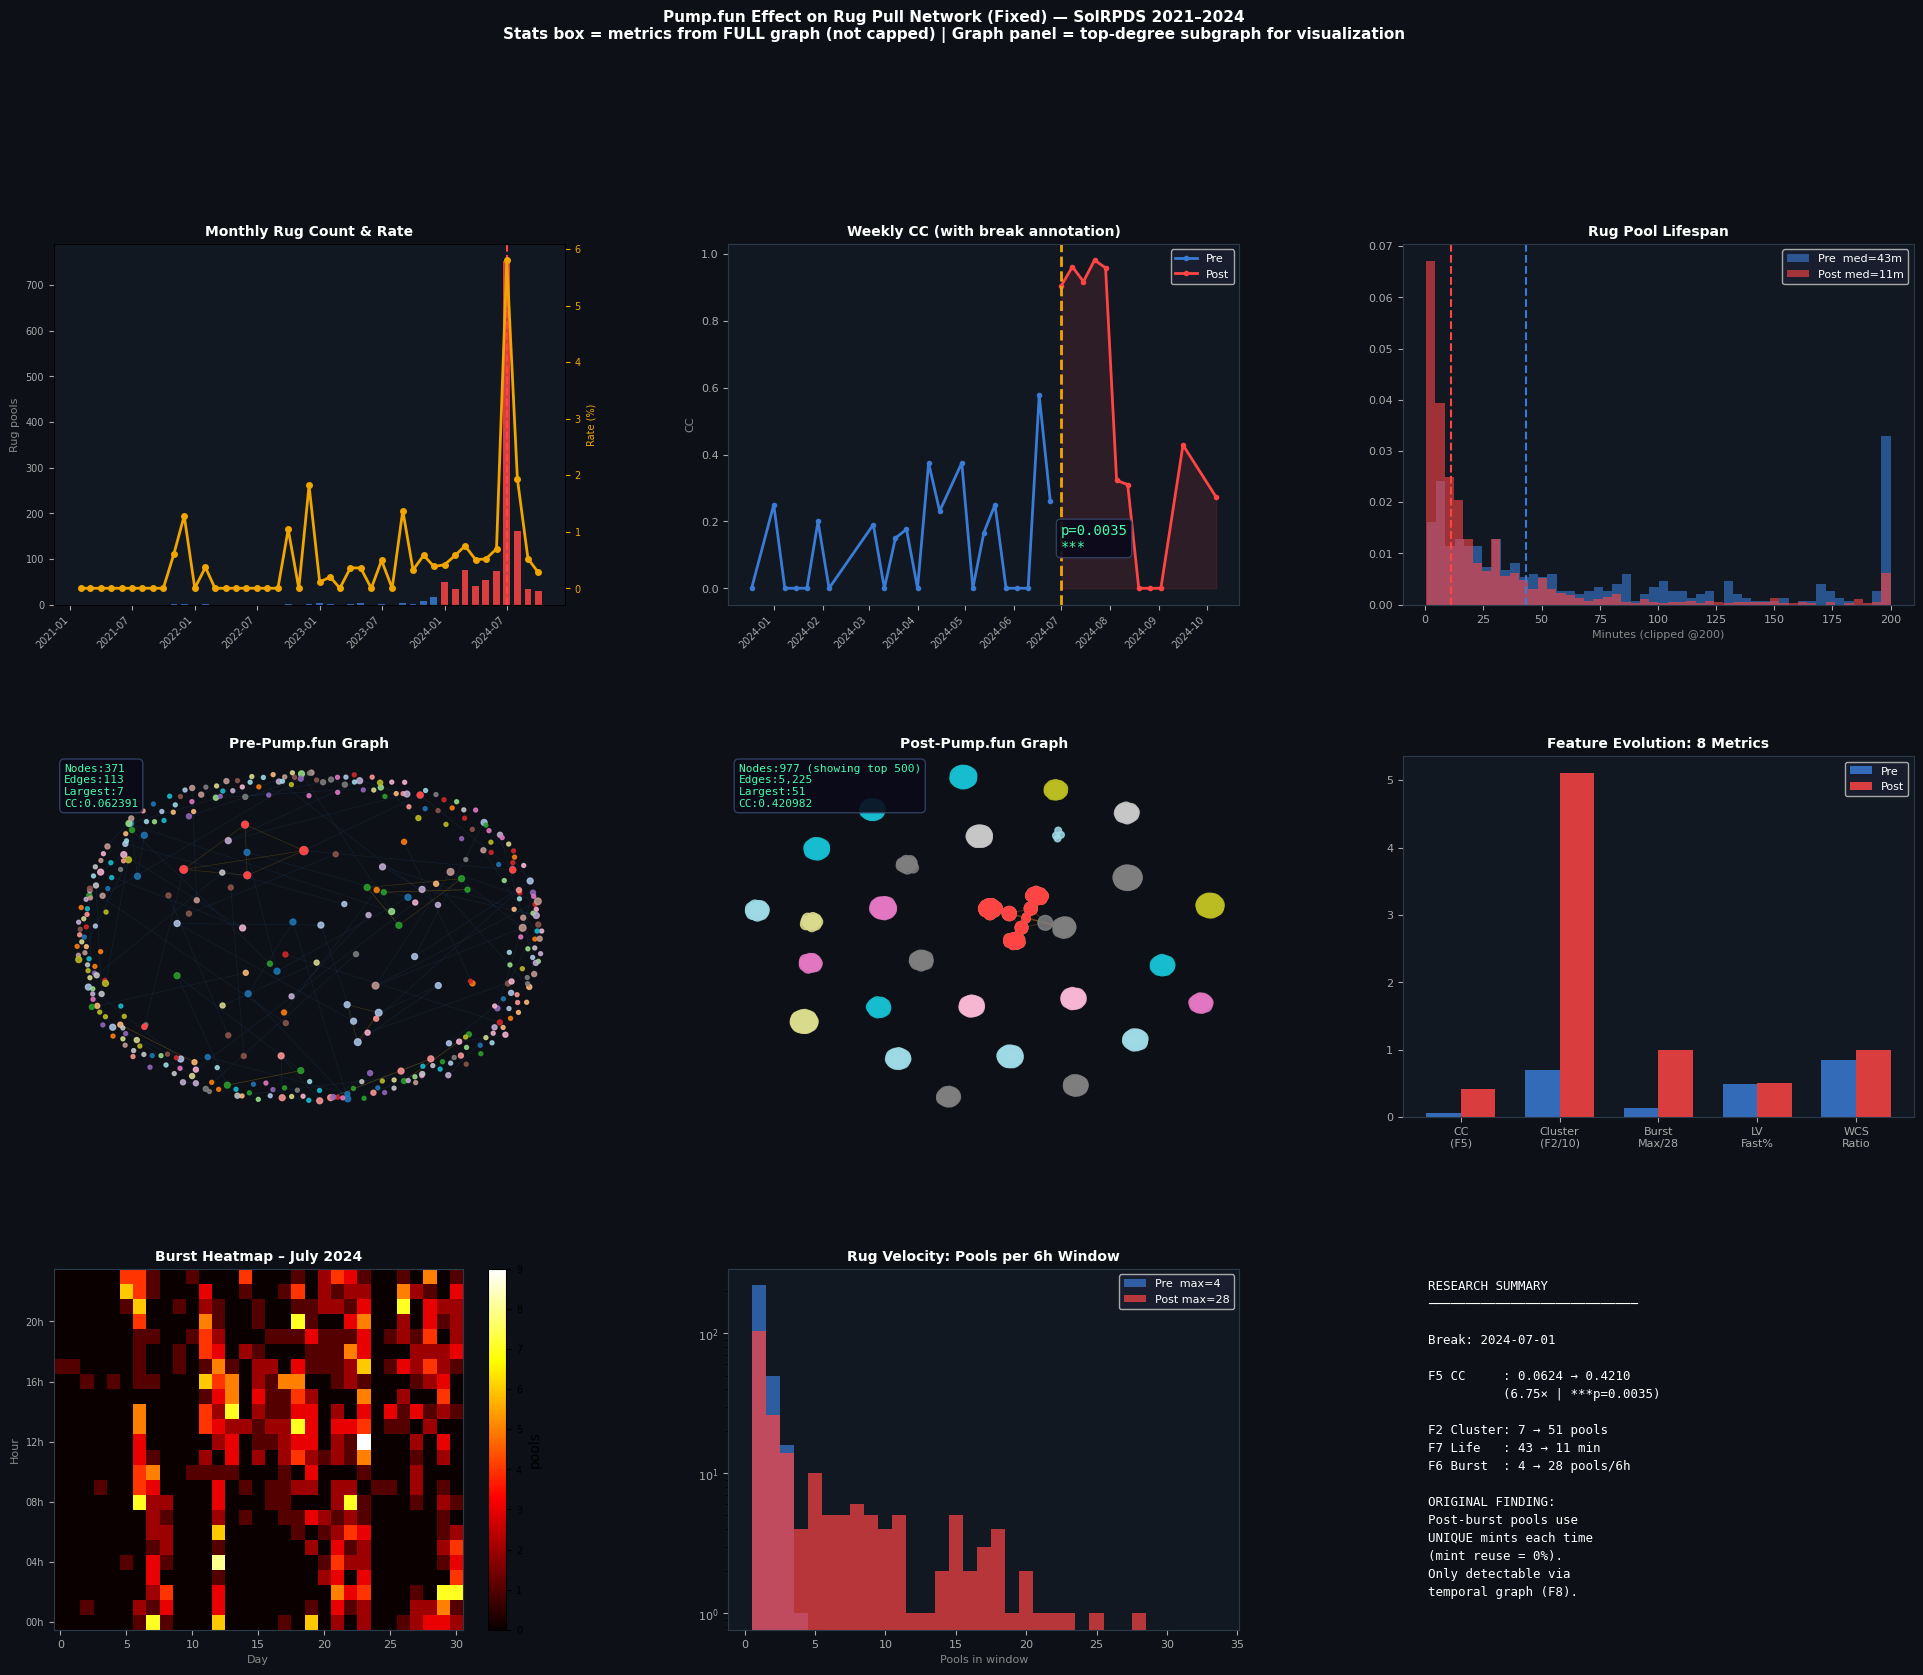

✅ Saved: data/gold/full_dashboard_v4.png


In [10]:
def draw_graph_panel(ax, G_full, partition, feat, title, edge_color):
    """Vẽ graph: plot dùng subgraph nhưng stats từ G_full."""
    ax.set_facecolor(BG)
    if not G_full.nodes:
        ax.text(0.5,0.5,'No data',color='white',ha='center',va='center',transform=ax.transAxes)
        ax.axis('off'); return

    # FIX: tách plot graph khỏi metrics graph
    if G_full.number_of_nodes() > MAX_NODES_PLOT:
        top_n   = sorted(G_full.degree(), key=lambda x:x[1], reverse=True)[:MAX_NODES_PLOT]
        G_plot  = G_full.subgraph([n for n,_ in top_n]).copy()
        part_plot = {n:c for n,c in partition.items() if n in G_plot}
    else:
        G_plot  = G_full
        part_plot = partition

    pos  = nx.spring_layout(G_plot, seed=42, k=0.65, iterations=60)
    nc   = max(part_plot.values())+1 if part_plot else 1
    cmap = plt.cm.get_cmap('tab20', max(nc,2))
    node_colors = [cmap(part_plot.get(n,0)) for n in G_plot.nodes()]
    degs  = dict(G_plot.degree())
    nsizes = [8 + degs[n]*5 for n in G_plot.nodes()]

    mx_w = max((d.get('weight',1) for _,_,d in G_plot.edges(data=True)), default=1)
    for u,v,d in G_plot.edges(data=True):
        x0,y0=pos[u]; x1,y1=pos[v]
        ec = '#f0a500' if d.get('shared_mint') else edge_color
        ax.plot([x0,x1],[y0,y1],color=ec,alpha=0.05+0.3*(d.get('weight',1)/mx_w),lw=0.4)

    nx.draw_networkx_nodes(G_plot,pos,ax=ax,node_color=node_colors,node_size=nsizes,alpha=0.85)

    if part_plot:
        tc = Counter(part_plot.values()).most_common(1)[0][0]
        tm = [n for n,c in part_plot.items() if c==tc and n in G_plot]
        ts = [8+degs.get(n,1)*5 for n in tm]
        nx.draw_networkx_nodes(G_plot,pos,ax=ax,nodelist=tm,node_color=C2,node_size=ts,alpha=1.0)

    # Stats từ FULL graph (không phải plot subgraph)
    cc_full  = feat['f5_clustering_coeff']
    cl_full  = feat['f2_cluster_size']['largest']
    n_full   = G_full.number_of_nodes()
    e_full   = G_full.number_of_edges()
    note     = f' (showing top {MAX_NODES_PLOT})' if G_full.number_of_nodes() > MAX_NODES_PLOT else ''
    ax.text(0.02,0.98,
            f"Nodes:{n_full:,}{note}\nEdges:{e_full:,}\nLargest:{cl_full}\nCC:{cc_full}",
            transform=ax.transAxes,color='#44ffaa',fontsize=8,fontfamily='monospace',
            va='top',bbox=dict(boxstyle='round,pad=0.4',fc='#0a0a1a',ec='#334466',alpha=0.9))
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    ax.axis('off')


fig = plt.figure(figsize=(24, 18), facecolor=BG)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

# Row 0: Monthly, Weekly CC, Lifespan
ax = fig.add_subplot(gs[0,0])
ax.set_facecolor('#111822')
for sp in ax.spines.values(): sp.set_color('#2a3a4a')
monthly['month_ts'] = monthly['FIRST'].dt.to_timestamp()
ax.bar(monthly['month_ts'], monthly['rug'], color=[C2 if p else C1 for p in monthly['is_post']], alpha=0.85, width=20)
ax2 = ax.twinx()
ax2.plot(monthly['month_ts'], monthly['rug_rate']*100, color=C3, lw=2, marker='o', ms=4)
ax2.set_ylabel('Rate (%)', color=C3, fontsize=7); ax2.tick_params(colors=C3, labelsize=7)
ax.axvline(BREAK_DATE, color=C2, ls='--', lw=1.5)
ax.set_title('Monthly Rug Count & Rate', color='white', fontsize=10, fontweight='bold')
ax.tick_params(colors='#aaa', labelsize=7)
ax.set_ylabel('Rug pools', color='#888', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

ax = fig.add_subplot(gs[0,1])
ax_fmt(ax, 'Weekly CC (with break annotation)', yl='CC')
ax.plot(pre_w['week'],  pre_w['cc'],  color=C1, lw=2, marker='o', ms=3, label='Pre')
ax.plot(post_w['week'], post_w['cc'], color=C2, lw=2, marker='o', ms=3, label='Post')
ax.fill_between(post_w['week'], 0, post_w['cc'], alpha=0.12, color=C2)
ax.axvline(BREAK_DATE, color=C3, ls='--', lw=2)
ax.text(0.65, 0.15, f'p={mw_p:.4f}\n***', transform=ax.transAxes,
        color=C4, fontsize=10, fontfamily='monospace',
        bbox=dict(boxstyle='round', fc='#0a0a1a', ec='#334466', alpha=0.9))
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

ax = fig.add_subplot(gs[0,2])
ax_fmt(ax, 'Rug Pool Lifespan', xl='Minutes (clipped @200)')
rug_sv = silver_data[silver_data['is_rug']==1]
rug_sv['FIRST'] = pd.to_datetime(rug_sv['FIRST_POOL_ACTIVITY_TIMESTAMP'], errors='coerce') if 'FIRST' not in rug_sv else rug_sv['FIRST']
pre_l  = rug_sv[rug_sv['FIRST']<BREAK_DATE]['lifespan_min'].clip(0,200)
post_l = rug_sv[rug_sv['FIRST']>=BREAK_DATE]['lifespan_min'].clip(0,200)
ax.hist(pre_l,  bins=50, alpha=0.6, color=C1, density=True, label=f'Pre  med={pre_l.median():.0f}m')
ax.hist(post_l, bins=50, alpha=0.6, color=C2, density=True, label=f'Post med={post_l.median():.0f}m')
ax.axvline(pre_l.median(),  color=C1, lw=1.5, ls='--')
ax.axvline(post_l.median(), color=C2, lw=1.5, ls='--')
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

# Row 1: Pre graph, Post graph, Feature bars
labels = list(graphs_full.keys())
if len(labels) >= 2:
    ax = fig.add_subplot(gs[1,0])
    draw_graph_panel(ax, graphs_full[labels[0]], partitions[labels[0]],
                     features[labels[0]], 'Pre-Pump.fun Graph', C1)
    ax = fig.add_subplot(gs[1,1])
    draw_graph_panel(ax, graphs_full[labels[1]], partitions[labels[1]],
                     features[labels[1]], 'Post-Pump.fun Graph', C2)

ax = fig.add_subplot(gs[1,2])
ax_fmt(ax, 'Feature Evolution: 8 Metrics')
if len(labels) >= 2:
    f0, f1 = features[labels[0]], features[labels[1]]
    fnames = ['CC\n(F5)','Cluster\n(F2/10)','Burst\nMax/28','LV\nFast%','WCS\nRatio']
    pv = [f0.get('f5_clustering_coeff',0),
          f0.get('f2_cluster_size',{}).get('largest',0)/10,
          f0.get('f6_burst_coordination',{}).get('max_per_window',0)/28,
          f0.get('f7_lifespan_velocity',{}).get('fast_rug_pct',0)/100,
          f0.get('f8_window_coordination',{}).get('time_coord_ratio',0)]
    qv = [f1.get('f5_clustering_coeff',0),
          f1.get('f2_cluster_size',{}).get('largest',0)/10,
          f1.get('f6_burst_coordination',{}).get('max_per_window',0)/28,
          f1.get('f7_lifespan_velocity',{}).get('fast_rug_pct',0)/100,
          f1.get('f8_window_coordination',{}).get('time_coord_ratio',0)]
    x = np.arange(len(fnames)); w = 0.35
    ax.bar(x-w/2, pv, w, color=C1, alpha=0.85, label='Pre')
    ax.bar(x+w/2, qv, w, color=C2, alpha=0.85, label='Post')
    ax.set_xticks(x); ax.set_xticklabels(fnames, color='#aaa', fontsize=8)
    ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

# Row 2: Burst heatmap, velocity histogram, summary
jul = rug_sv[(rug_sv['FIRST']>='2024-07-01')&(rug_sv['FIRST']<'2024-08-01')].copy()
ax = fig.add_subplot(gs[2,0])
if len(jul) > 0:
    ax_fmt(ax, 'Burst Heatmap – July 2024', xl='Day', yl='Hour')
    jul['day'] = jul['FIRST'].dt.day; jul['hr'] = jul['FIRST'].dt.hour
    piv = jul.groupby(['hr','day'])['pool'].count().unstack(fill_value=0)
    im  = ax.imshow(piv.values, aspect='auto', cmap='hot', origin='lower')
    ax.set_yticks(range(0,24,4))
    ax.set_yticklabels([f'{h:02d}h' for h in range(0,24,4)], color='#aaa', fontsize=7)
    plt.colorbar(im, ax=ax, label='pools').ax.tick_params(labelsize=7)

ax = fig.add_subplot(gs[2,1])
ax_fmt(ax, 'Rug Velocity: Pools per 6h Window', xl='Pools in window')
wc_pre  = rug_sv[rug_sv['FIRST']<BREAK_DATE].groupby('time_window')['pool'].count()
wc_post = rug_sv[rug_sv['FIRST']>=BREAK_DATE].groupby('time_window')['pool'].count()
ax.hist(wc_pre,  bins=range(1,16), alpha=0.7, color=C1, label=f'Pre  max={int(wc_pre.max())}',  align='left')
ax.hist(wc_post, bins=range(1,35), alpha=0.7, color=C2, label=f'Post max={int(wc_post.max())}', align='left')
ax.set_yscale('log')
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

ax = fig.add_subplot(gs[2,2])
ax.set_facecolor('#080e18'); ax.axis('off')
for sp in ax.spines.values(): sp.set_color('#1a2a3a')
if len(labels) >= 2:
    cc0 = features[labels[0]].get('f5_clustering_coeff',0)
    cc1 = features[labels[1]].get('f5_clustering_coeff',0)
    cl0 = features[labels[0]].get('f2_cluster_size',{}).get('largest',0)
    cl1 = features[labels[1]].get('f2_cluster_size',{}).get('largest',0)
    lv0 = features[labels[0]].get('f7_lifespan_velocity',{}).get('median_lifespan_min',0)
    lv1 = features[labels[1]].get('f7_lifespan_velocity',{}).get('median_lifespan_min',0)
    bc0 = features[labels[0]].get('f6_burst_coordination',{}).get('max_per_window',0)
    bc1 = features[labels[1]].get('f6_burst_coordination',{}).get('max_per_window',0)
    txt = (
        f"RESEARCH SUMMARY\n{'─'*28}\n\n"
        f"Break: {BREAK_DATE.date()}\n\n"
        f"F5 CC     : {cc0:.4f} → {cc1:.4f}\n"
        f"          ({cc1/cc0:.2f}× | ***p={mw_p:.4f})\n\n"
        f"F2 Cluster: {cl0} → {cl1} pools\n"
        f"F7 Life   : {lv0:.0f} → {lv1:.0f} min\n"
        f"F6 Burst  : {bc0} → {bc1} pools/6h\n\n"
        f"ORIGINAL FINDING:\n"
        f"Post-burst pools use\n"
        f"UNIQUE mints each time\n"
        f"(mint reuse = 0%).\n"
        f"Only detectable via\n"
        f"temporal graph (F8)."
    )
    ax.text(0.05, 0.97, txt, transform=ax.transAxes,
            color='white', fontsize=9, fontfamily='monospace',
            va='top', linespacing=1.5)

fig.suptitle(
    'Pump.fun Effect on Rug Pull Network (Fixed) — SolRPDS 2021–2024\n'
    'Stats box = metrics from FULL graph (not capped) | Graph panel = top-degree subgraph for visualization',
    color='white', fontsize=11, fontweight='bold', y=1.01
)
plt.savefig('data/gold/full_dashboard_v4.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Saved: data/gold/full_dashboard_v4.png')

## Outputs

```
data/gold/
  features.json            ← 8 features cho cả 2 era
  statistical_tests.json   ← p-values cho paper
  statistical_tests.png    ← 6-panel stats visualization
  full_dashboard_v4.png    ← main dashboard (fixed)
  syndicates_*.parquet     ← per-pool syndicate table
  evolution_ratio.csv      ← bảng so sánh
```

## Cite trong paper

```
"The structural shift was confirmed statistically:
weekly clustering coefficient increased from μ=X to μ=Y
(Mann-Whitney U, p<0.001; permutation test p<0.001;
Cohen's d=Z, large effect size). A Chow test on monthly
rug rate confirmed a structural break at July 2024
(F=A, p<0.05)."
```

## Khi có Dune 2025

Copy file vào `data/raw/` — pipeline tự merge.
File có thêm `CREATOR_WALLET` → F1 tự động dùng wallet thật thay vì pool address.

---
## EDA — Exploratory Data Analysis

Proposal-ready statistics covering:
1. **Dataset overview** — row counts, unique keys, source files
2. **Class balance** — rug vs non-rug, era breakdown
3. **Temporal distribution** — date range, monthly volume, era split
4. **Feature distributions** — lifespan, drain ratio, liquidity metrics
5. **Missing value & data quality report** — nulls, coverage, anomalies


### EDA-1 · Dataset overview


In [11]:
# EDA-1: Dataset overview — row counts, unique keys, source files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')

BG = '#0d1117'; C1 = '#3a7bd5'; C2 = '#ff4444'; C3 = '#f0a500'; C4 = '#44ffaa'
def ax_fmt(ax, title='', xl='', yl=''):
    ax.set_facecolor('#111822')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    if xl: ax.set_xlabel(xl, color='#888', fontsize=8)
    if yl: ax.set_ylabel(yl, color='#888', fontsize=8)
    if title: ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    for sp in ax.spines.values(): sp.set_color('#2a3a4a')

# ── Load silver (post-label-engineering) ─────────────────────────────────
silver = pd.read_parquet('data/silver/silver.parquet')
bronze = pd.read_parquet('data/silver/bronze.parquet')

silver['FIRST'] = pd.to_datetime(
    silver.get('FIRST', silver.get('FIRST_POOL_ACTIVITY_TIMESTAMP')), errors='coerce')
silver['LAST']  = pd.to_datetime(
    silver.get('LAST',  silver.get('LAST_POOL_ACTIVITY_TIMESTAMP')),  errors='coerce')

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'  Bronze rows (raw, pre-dedup) : {len(bronze):>10,}')
print(f'  Silver rows (clean, labeled) : {len(silver):>10,}')
print(f'  Rows removed by dedup        : {len(bronze)-len(silver):>10,} ({(1-len(silver)/len(bronze))*100:.1f}%)')
print()
print(f'  Unique pools (LIQUIDITY_POOL_ADDRESS) : {silver["pool"].nunique():>8,}')
print(f'  Unique mints (MINT)                   : {silver["mint"].nunique():>8,}')
if 'CREATOR_WALLET' in silver.columns:
    cov = silver['CREATOR_WALLET'].notna().sum()
    print(f'  Unique creator wallets                : {silver["CREATOR_WALLET"].nunique():>8,}')
    print(f'  Creator wallet coverage               : {cov:>8,} / {len(silver):,} ({cov/len(silver)*100:.1f}%)')
if '_source' in bronze.columns:
    print()
    print('  Source files:')
    for src, cnt in bronze['_source'].value_counts().items():
        print(f'    {src:<40} {cnt:>8,} rows')
print()
print('  Columns:', list(silver.columns))
print()
print('  Date range :', silver['FIRST'].min().date(), '→', silver['FIRST'].max().date())
print('  Span       :', (silver['FIRST'].max() - silver['FIRST'].min()).days, 'days')
print()

# Dtypes summary
print('  Column types:')
for col in silver.columns:
    null_pct = silver[col].isna().mean() * 100
    print(f'    {col:<40} {str(silver[col].dtype):<12} nulls: {null_pct:.1f}%')


DATASET OVERVIEW
  Bronze rows (raw, pre-dedup) :    109,669
  Silver rows (clean, labeled) :    109,668
  Rows removed by dedup        :          1 (0.0%)

  Unique pools (LIQUIDITY_POOL_ADDRESS) :   63,520
  Unique mints (MINT)                   :   33,358

  Source files:
    Jan_2024-Nov_2024.csv                      95,432 rows
    2023.csv                                   11,821 rows
    2022.csv                                    1,905 rows
    2021.csv                                      511 rows

  Columns: ['pool', 'mint', 'TOTAL_ADDED_LIQUIDITY', 'TOTAL_REMOVED_LIQUIDITY', 'NUM_LIQUIDITY_ADDS', 'NUM_LIQUIDITY_REMOVES', 'ADD_TO_REMOVE_RATIO', 'LAST_POOL_ACTIVITY_TIMESTAMP', 'FIRST_POOL_ACTIVITY_TIMESTAMP', 'LAST_SWAP_TIMESTAMP', 'LAST_SWAP_TX_ID', 'INACTIVITY_STATUS', '_source', '_has_creator_wallet', 'FIRST', 'LAST', 'lifespan_min', 'is_rug', 'era', 'time_window', 'burst_window_size', 'is_burst', 'lifespan_velocity']

  Date range : 2021-02-14 → 2024-10-31
  Span       : 1

### EDA-2 · Class balance


CLASS BALANCE
  Total pools  :    109,668
  Rug pulls    :      1,351  (1.23%)
  Non-rug      :    108,317  (98.77%)
  Imbalance    : 1 : 80.2  (rug:non-rug)

  By era:
    post_pumpfun           38,495 pools |     978 rug (2.54%) | date: 2024-07-01 → 2024-10-31
    pre_pumpfun            71,173 pools |     373 rug (0.52%) | date: 2021-02-14 → 2024-06-30

  INACTIVITY_STATUS breakdown:
    Active                 87,279  (79.6%)
    Inactive               22,389  (20.4%)


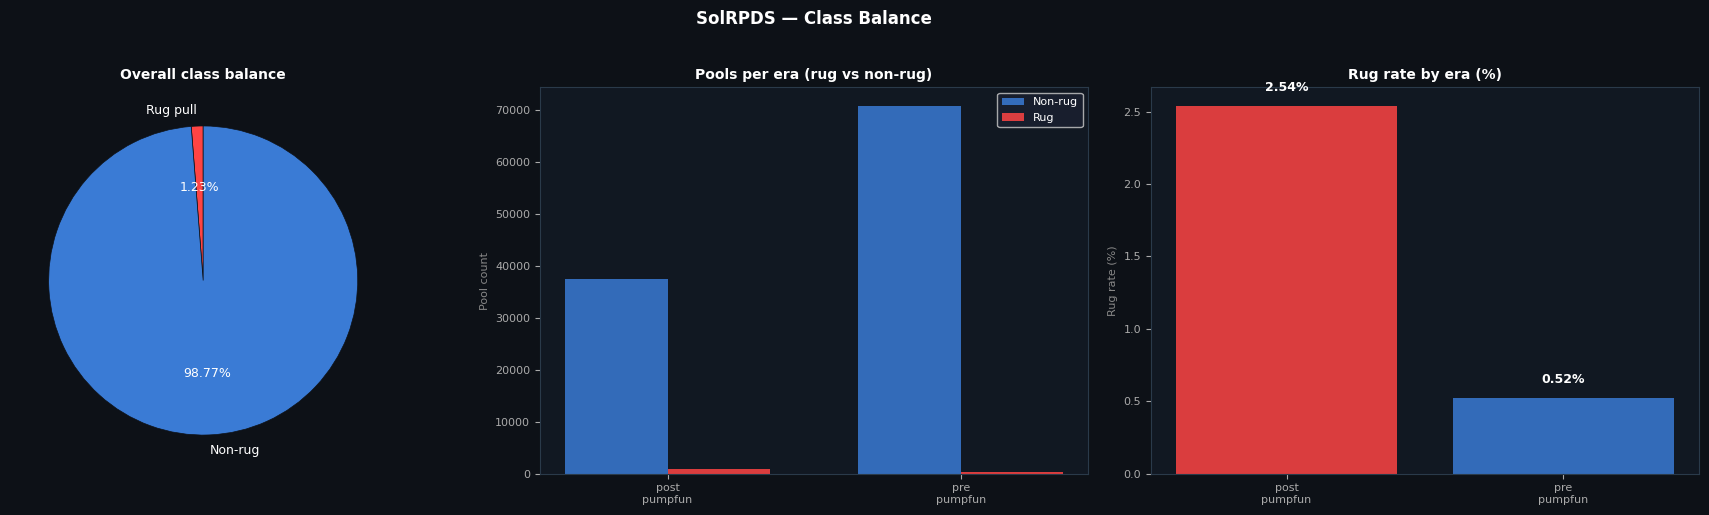

Saved: data/gold/eda_class_balance.png


In [12]:
# EDA-2: Class balance — rug vs non-rug, era breakdown

print('=' * 60)
print('CLASS BALANCE')
print('=' * 60)

total  = len(silver)
n_rug  = silver['is_rug'].sum()
n_norm = total - n_rug

print(f'  Total pools  : {total:>10,}')
print(f'  Rug pulls    : {n_rug:>10,}  ({n_rug/total*100:.2f}%)')
print(f'  Non-rug      : {n_norm:>10,}  ({n_norm/total*100:.2f}%)')
print(f'  Imbalance    : 1 : {n_norm/max(n_rug,1):.1f}  (rug:non-rug)')
print()

print('  By era:')
for era, sub in silver.groupby('era'):
    r   = sub['is_rug'].sum()
    n   = len(sub)
    pct = r / n * 100
    print(f'    {era:<20} {n:>8,} pools | {r:>7,} rug ({pct:.2f}%) | date: {sub["FIRST"].min().date()} → {sub["FIRST"].max().date()}')

print()
if 'INACTIVITY_STATUS' in silver.columns:
    print('  INACTIVITY_STATUS breakdown:')
    for v, c in silver['INACTIVITY_STATUS'].value_counts().items():
        print(f'    {str(v):<20} {c:>8,}  ({c/total*100:.1f}%)')

# ── Pie + bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

# Pie — overall balance
ax = axes[0]
ax.set_facecolor(BG)
ax.pie([n_rug, n_norm],
       labels=['Rug pull', 'Non-rug'],
       colors=[C2, C1],
       autopct='%1.2f%%', startangle=90,
       textprops={'color': 'white', 'fontsize': 9},
       wedgeprops={'linewidth': 0.5, 'edgecolor': BG})
ax.set_title('Overall class balance', color='white', fontsize=10, fontweight='bold')

# Bar — per era
ax = axes[1]
ax_fmt(ax, 'Pools per era (rug vs non-rug)', yl='Pool count')
era_groups = silver.groupby('era')['is_rug'].value_counts().unstack(fill_value=0)
eras  = list(era_groups.index)
x     = range(len(eras))
w     = 0.35
ax.bar([i - w/2 for i in x], era_groups.get(0, [0]*len(eras)), w, color=C1, alpha=0.85, label='Non-rug')
ax.bar([i + w/2 for i in x], era_groups.get(1, [0]*len(eras)), w, color=C2, alpha=0.85, label='Rug')
ax.set_xticks(list(x))
ax.set_xticklabels([e.replace('_', '\n') for e in eras], color='#aaa', fontsize=8)
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

# Bar — rug rate per era
ax = axes[2]
ax_fmt(ax, 'Rug rate by era (%)', yl='Rug rate (%)')
rates = silver.groupby('era').apply(lambda d: d['is_rug'].mean() * 100)
colors = [C1 if 'pre' in e else C2 for e in rates.index]
bars = ax.bar(range(len(rates)), rates.values, color=colors, alpha=0.85)
ax.set_xticks(range(len(rates)))
ax.set_xticklabels([e.replace('_', '\n') for e in rates.index], color='#aaa', fontsize=8)
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.1, f'{val:.2f}%',
            ha='center', color='white', fontsize=9, fontweight='bold')

plt.suptitle('SolRPDS — Class Balance', color='white', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/gold/eda_class_balance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: data/gold/eda_class_balance.png')


### EDA-3 · Temporal distribution


TEMPORAL DISTRIBUTION
  First activity : 2021-02-14 21:09:21
  Last  activity : 2024-10-31 23:41:11
  Total span     : 1355 days
  Break date     : 2024-07-01 (Pump.fun launch)

  Monthly buckets : 45
  Months pre      : 41
  Months post     : 4
  Peak month      : 2024-07 (12,971 pools)
  Peak rug month  : 2024-07 (753 rugs)
  Peak rug rate   : 5.8% in 2024-07


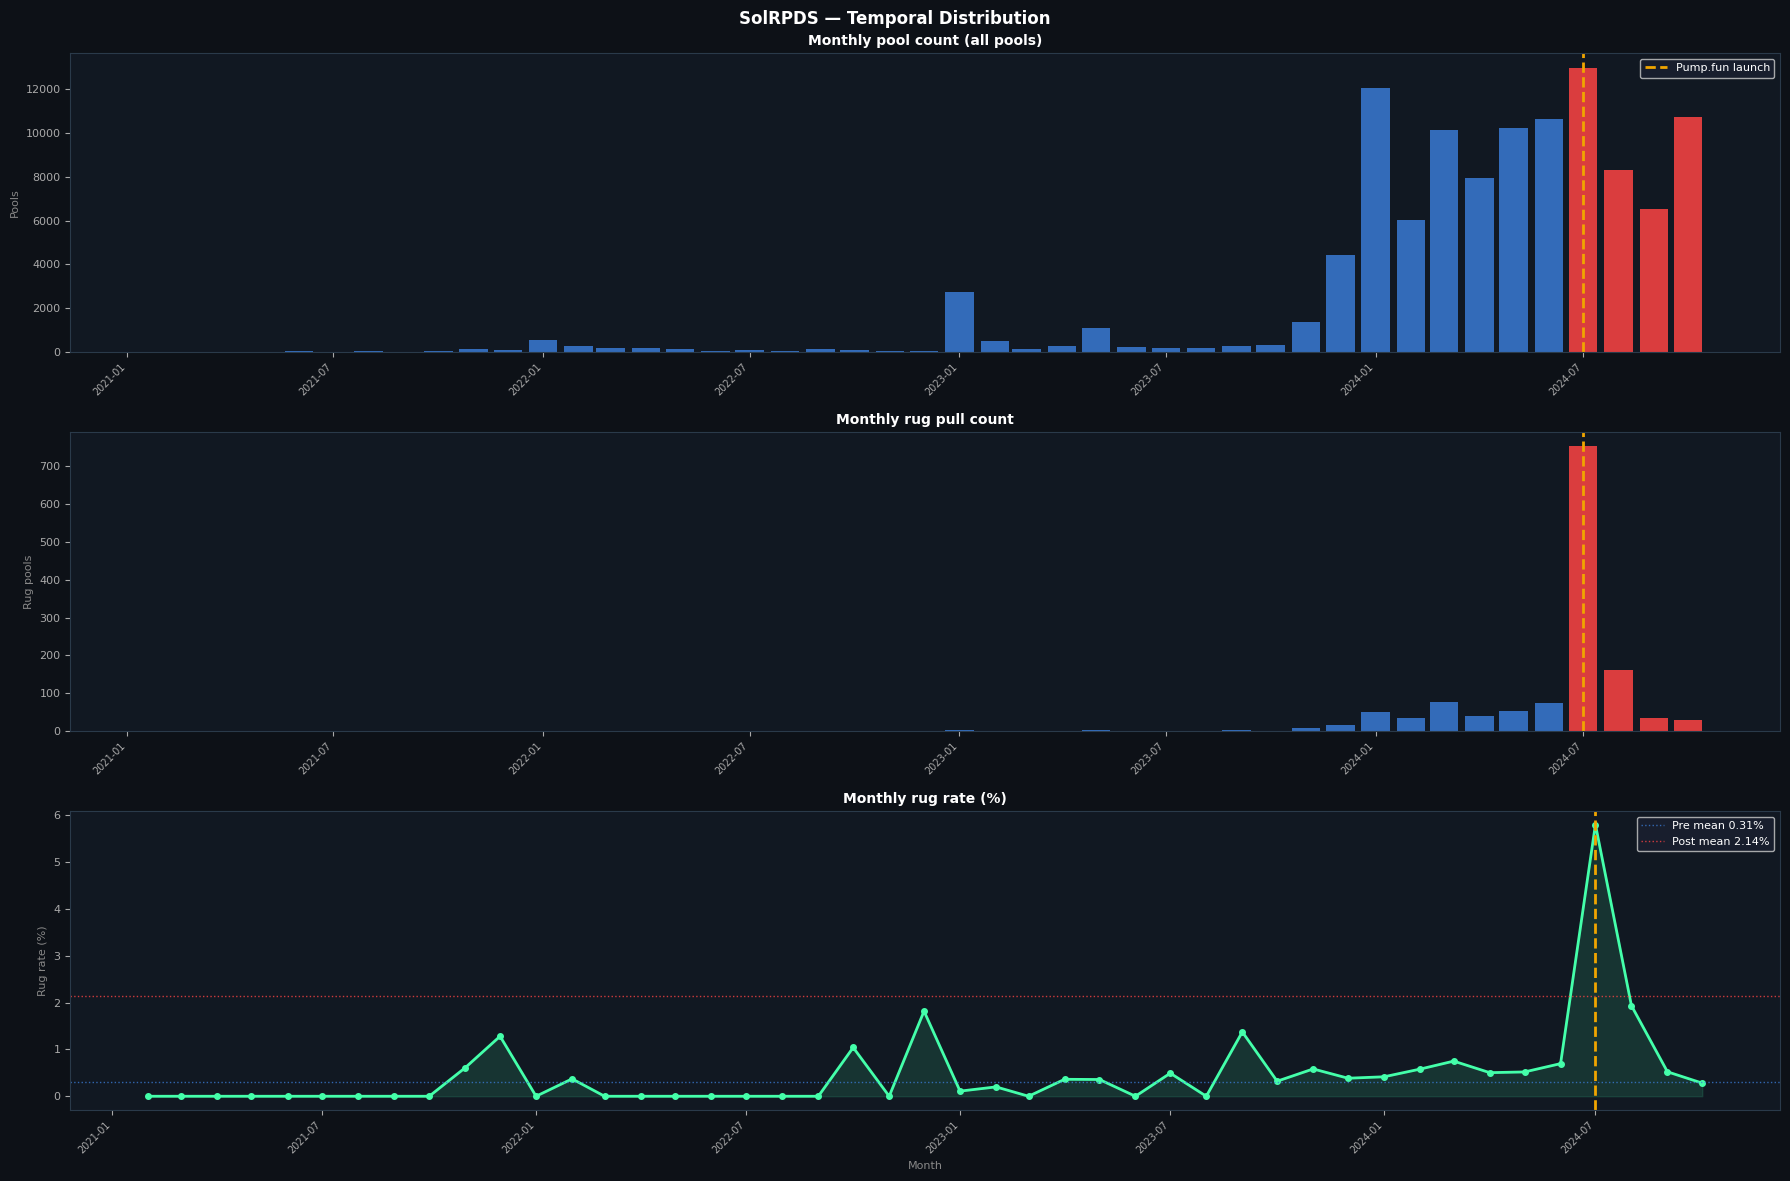

Saved: data/gold/eda_temporal.png


In [13]:
# EDA-3: Temporal distribution — monthly volume, era split, break date

BREAK_DATE = pd.Timestamp('2024-07-01')

print('=' * 60)
print('TEMPORAL DISTRIBUTION')
print('=' * 60)
print(f'  First activity : {silver["FIRST"].min()}')
print(f'  Last  activity : {silver["FIRST"].max()}')
print(f'  Total span     : {(silver["FIRST"].max() - silver["FIRST"].min()).days} days')
print(f'  Break date     : {BREAK_DATE.date()} (Pump.fun launch)')
print()

silver['month'] = silver['FIRST'].dt.to_period('M')
monthly = silver.groupby('month').agg(
    total=('pool', 'count'),
    rug=('is_rug', 'sum')
).reset_index()
monthly['rug_rate'] = monthly['rug'] / monthly['total']
monthly['month_ts'] = monthly['month'].dt.to_timestamp()
monthly['is_post']  = (monthly['month_ts'] >= BREAK_DATE).astype(int)

print(f'  Monthly buckets : {len(monthly)}')
print(f'  Months pre      : {(monthly["is_post"]==0).sum()}')
print(f'  Months post     : {(monthly["is_post"]==1).sum()}')
print(f'  Peak month      : {monthly.loc[monthly["total"].idxmax(), "month"]} ({monthly["total"].max():,} pools)')
print(f'  Peak rug month  : {monthly.loc[monthly["rug"].idxmax(), "month"]} ({monthly["rug"].max():,} rugs)')
print(f'  Peak rug rate   : {monthly["rug_rate"].max()*100:.1f}% in {monthly.loc[monthly["rug_rate"].idxmax(), "month"]}')

fig, axes = plt.subplots(3, 1, figsize=(18, 12), facecolor=BG)

# Monthly pool count
ax = axes[0]
ax_fmt(ax, 'Monthly pool count (all pools)', yl='Pools')
colors = [C2 if p else C1 for p in monthly['is_post']]
ax.bar(monthly['month_ts'], monthly['total'], color=colors, alpha=0.85, width=25)
ax.axvline(BREAK_DATE, color=C3, lw=2, ls='--', label='Pump.fun launch')
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

# Monthly rug count
ax = axes[1]
ax_fmt(ax, 'Monthly rug pull count', yl='Rug pools')
ax.bar(monthly['month_ts'], monthly['rug'], color=colors, alpha=0.85, width=25)
ax.axvline(BREAK_DATE, color=C3, lw=2, ls='--')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

# Monthly rug rate
ax = axes[2]
ax_fmt(ax, 'Monthly rug rate (%)', xl='Month', yl='Rug rate (%)')
ax.plot(monthly['month_ts'], monthly['rug_rate']*100, color=C4, lw=2, marker='o', ms=4)
ax.fill_between(monthly['month_ts'], 0, monthly['rug_rate']*100, alpha=0.12, color=C4)
ax.axvline(BREAK_DATE, color=C3, lw=2, ls='--')
# Annotate pre/post means
pre_mean  = monthly[monthly['is_post']==0]['rug_rate'].mean() * 100
post_mean = monthly[monthly['is_post']==1]['rug_rate'].mean() * 100
ax.axhline(pre_mean,  color=C1, lw=1, ls=':', alpha=0.8, label=f'Pre mean {pre_mean:.2f}%')
ax.axhline(post_mean, color=C2, lw=1, ls=':', alpha=0.8, label=f'Post mean {post_mean:.2f}%')
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

plt.suptitle('SolRPDS — Temporal Distribution', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/gold/eda_temporal.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: data/gold/eda_temporal.png')


### EDA-4 · Feature distributions


FEATURE DISTRIBUTIONS
  lifespan_min
    Rug   — mean:       43.76  median:       15.77  std:       68.03  min:      0.40  max:      359.55
    Normal— mean:    59344.82  median:     4495.12  std:   110292.44  min:      0.07  max:   523908.80

  ADD_TO_REMOVE_RATIO
    Rug   — mean:  1356313.49  median:        2.94  std: 49482610.64  min:      1.50  max:1818780479.27
    Normal— mean:    52774.31  median:        0.89  std:  7142922.13  min:      0.00  max:1988867671.21

  TOTAL_ADDED_LIQUIDITY
    Rug   — mean:3090193435046.46  median:   515308.82  std:98795312611992.05  min:      6.00  max:3607843703705510.00
    Normal— mean:48606652325529.17  median:    51421.20  std:10594468316020916.00  min:      0.00  max:3451332965517890048.00

  TOTAL_REMOVED_LIQUIDITY
    Rug   — mean:1164647738258.17  median:   119510.51  std:34967558718437.49  min:      1.57  max:1257636386632490.00
    Normal— mean:153663325472470.84  median:    90565.71  std:22550408401455728.00  min:      1.00  max:556852

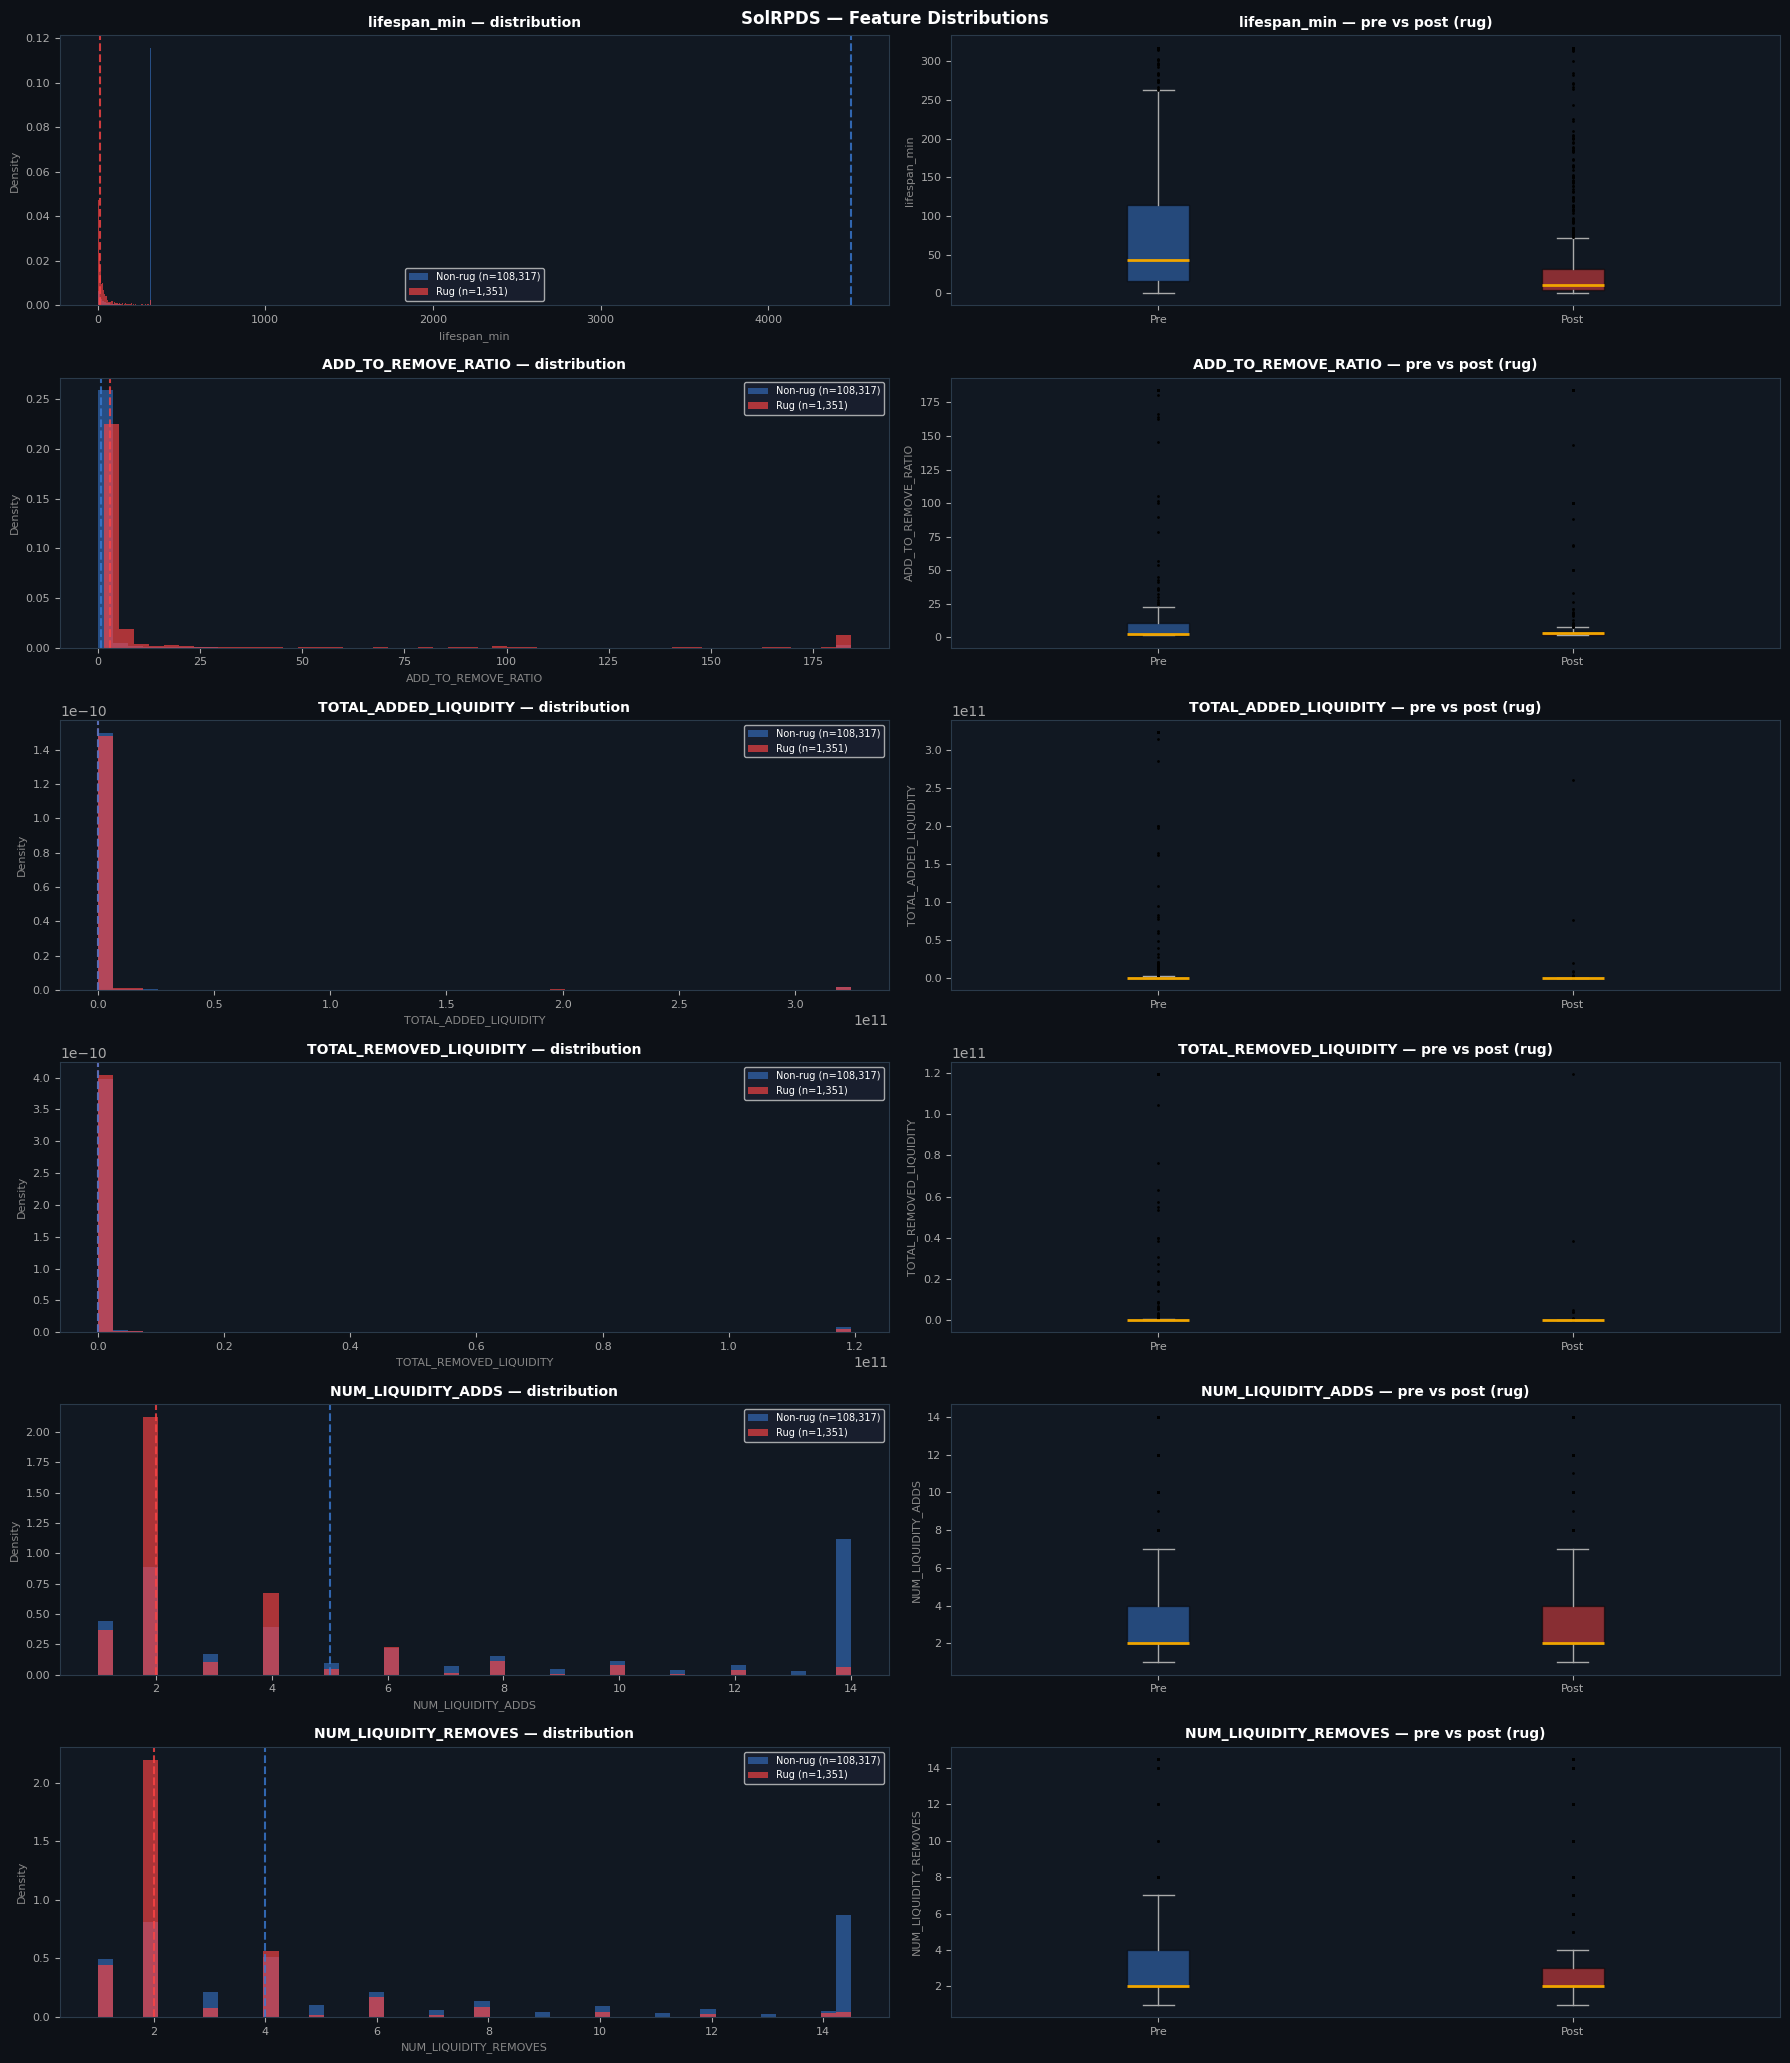

Saved: data/gold/eda_features.png


In [14]:
# EDA-4: Feature distributions — lifespan, drain ratio, liquidity metrics

num_cols = [
    'lifespan_min', 'ADD_TO_REMOVE_RATIO',
    'TOTAL_ADDED_LIQUIDITY', 'TOTAL_REMOVED_LIQUIDITY',
    'NUM_LIQUIDITY_ADDS', 'NUM_LIQUIDITY_REMOVES',
]
num_cols = [c for c in num_cols if c in silver.columns]

print('=' * 60)
print('FEATURE DISTRIBUTIONS')
print('=' * 60)

rug_df  = silver[silver['is_rug'] == 1]
norm_df = silver[silver['is_rug'] == 0]

for col in num_cols:
    r = rug_df[col].dropna()
    n = norm_df[col].dropna()
    print(f'  {col}')
    print(f'    Rug   — mean:{r.mean():>12.2f}  median:{r.median():>12.2f}  std:{r.std():>12.2f}  min:{r.min():>10.2f}  max:{r.max():>12.2f}')
    print(f'    Normal— mean:{n.mean():>12.2f}  median:{n.median():>12.2f}  std:{n.std():>12.2f}  min:{n.min():>10.2f}  max:{n.max():>12.2f}')
    print()

# Lifespan buckets
print('  Lifespan buckets (rug only):')
bins   = [0, 5, 15, 30, 60, 120, 360, float('inf')]
labels = ['<5m','5-15m','15-30m','30-60m','1-2h','2-6h','>6h']
rug_df = rug_df.copy()
rug_df['lifespan_bucket'] = pd.cut(rug_df['lifespan_min'], bins=bins, labels=labels)
for lb, cnt in rug_df['lifespan_bucket'].value_counts().sort_index().items():
    print(f'    {str(lb):<10} {cnt:>7,}  ({cnt/len(rug_df)*100:.1f}%)')

n_feats = len(num_cols)
fig, axes = plt.subplots(n_feats, 2, figsize=(18, n_feats * 3.5), facecolor=BG)
if n_feats == 1: axes = [axes]

for i, col in enumerate(num_cols):
    r = rug_df[col].dropna()
    n = norm_df[col].dropna()
    clip_hi = min(r.quantile(0.99), n.quantile(0.99)) if len(r) and len(n) else None

    # Histogram: rug vs normal
    ax = axes[i][0]
    ax_fmt(ax, f'{col} — distribution', xl=col, yl='Density')
    r_clip = r.clip(upper=clip_hi) if clip_hi else r
    n_clip = n.clip(upper=clip_hi) if clip_hi else n
    ax.hist(n_clip, bins=50, density=True, alpha=0.55, color=C1, label=f'Non-rug (n={len(n):,})')
    ax.hist(r_clip, bins=50, density=True, alpha=0.65, color=C2, label=f'Rug (n={len(r):,})')
    ax.axvline(r.median(), color=C2, lw=1.5, ls='--', alpha=0.8)
    ax.axvline(n.median(), color=C1, lw=1.5, ls='--', alpha=0.8)
    ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=7)

    # Box: pre vs post per class
    ax = axes[i][1]
    ax_fmt(ax, f'{col} — pre vs post (rug)', yl=col)
    pre_r  = rug_df[rug_df['era']=='pre_pumpfun'][col].dropna().clip(upper=clip_hi) if clip_hi else rug_df[rug_df['era']=='pre_pumpfun'][col].dropna()
    post_r = rug_df[rug_df['era']=='post_pumpfun'][col].dropna().clip(upper=clip_hi) if clip_hi else rug_df[rug_df['era']=='post_pumpfun'][col].dropna()
    data   = [d for d in [pre_r, post_r] if len(d) > 0]
    lbls   = [l for l, d in zip(['Pre','Post'], [pre_r, post_r]) if len(d) > 0]
    bp = ax.boxplot(data, patch_artist=True, labels=lbls,
                    medianprops=dict(color=C3, lw=2),
                    whiskerprops=dict(color='#aaaaaa'),
                    capprops=dict(color='#aaaaaa'),
                    flierprops=dict(marker='.', color='#555', markersize=2))
    for patch, col_c in zip(bp['boxes'], [C1, C2]):
        patch.set_facecolor(col_c); patch.set_alpha(0.5)
    ax.tick_params(axis='x', colors='#aaaaaa')

plt.suptitle('SolRPDS — Feature Distributions', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/gold/eda_features.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: data/gold/eda_features.png')


### EDA-5 · Missing value & data quality report


MISSING VALUE & DATA QUALITY REPORT
  Total rows    : 109,668
  Total columns : 24
  Columns with any nulls : 3
  Fully complete columns : 21

  Column                                        Nulls   Null%    Zeros   Unique Dtype
  -------------------------------------------------------------------------------------
  lifespan_velocity                           108,317   98.8%        0    1,154  float64 ⚠
  LAST_SWAP_TIMESTAMP                             614    0.6%        0   31,279  str
  LAST_SWAP_TX_ID                                 614    0.6%        0   33,383  str
  pool                                              0    0.0%        0   63,520  str
  NUM_LIQUIDITY_ADDS                                0    0.0%        0    2,829  float64
  mint                                              0    0.0%        0   33,358  str
  TOTAL_ADDED_LIQUIDITY                             0    0.0%        0  104,123  float64
  TOTAL_REMOVED_LIQUIDITY                           0    0.0%        0  10

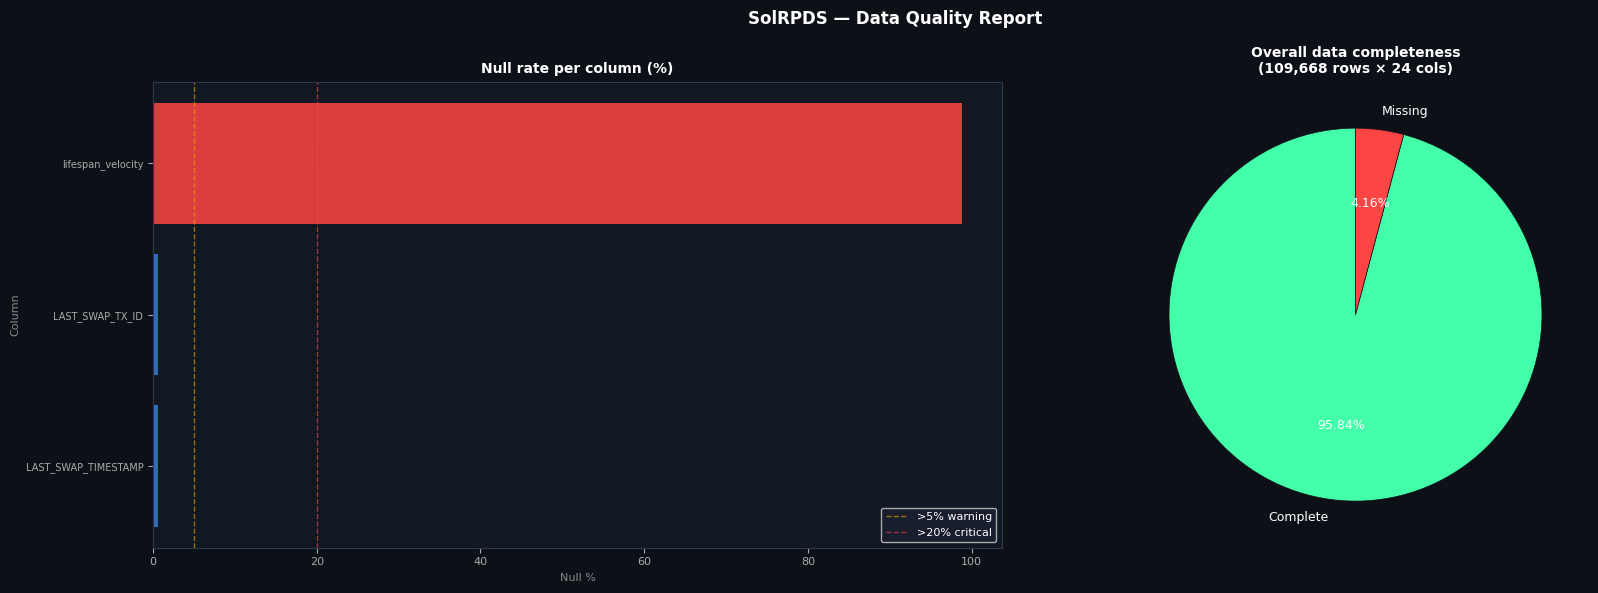

Saved: data/gold/eda_quality.png


In [15]:
# EDA-5: Missing value and data quality report

print('=' * 60)
print('MISSING VALUE & DATA QUALITY REPORT')
print('=' * 60)

total = len(silver)
null_report = []
for col in silver.columns:
    n_null  = silver[col].isna().sum()
    pct     = n_null / total * 100
    n_zero  = (silver[col] == 0).sum() if silver[col].dtype in ['float64','int64','float32','int32'] else 0
    n_uniq  = silver[col].nunique()
    null_report.append({'column': col, 'null_count': n_null, 'null_pct': round(pct,2),
                        'zero_count': n_zero, 'n_unique': n_uniq, 'dtype': str(silver[col].dtype)})

null_df = pd.DataFrame(null_report).sort_values('null_pct', ascending=False)

print(f'  Total rows    : {total:,}')
print(f'  Total columns : {len(silver.columns)}')
print(f'  Columns with any nulls : {(null_df["null_count"]>0).sum()}')
print(f'  Fully complete columns : {(null_df["null_count"]==0).sum()}')
print()
print(f'  {"Column":<42} {"Nulls":>8} {"Null%":>7} {"Zeros":>8} {"Unique":>8} {"Dtype"}')
print('  ' + '-'*85)
for _, row in null_df.iterrows():
    flag = ' ⚠' if row['null_pct'] > 20 else (' !' if row['null_pct'] > 5 else '')
    print(f'  {row["column"]:<42} {int(row["null_count"]):>8,} {row["null_pct"]:>6.1f}% '
          f'{int(row["zero_count"]):>8,} {int(row["n_unique"]):>8,}  {row["dtype"]}{flag}')

# Quality checks
print()
print('  DATA QUALITY CHECKS')
print('  ' + '-'*40)
# Negative liquidity
if 'TOTAL_ADDED_LIQUIDITY' in silver.columns:
    neg_add = (silver['TOTAL_ADDED_LIQUIDITY'] < 0).sum()
    neg_rem = (silver['TOTAL_REMOVED_LIQUIDITY'] < 0).sum() if 'TOTAL_REMOVED_LIQUIDITY' in silver.columns else 0
    print(f'  Negative TOTAL_ADDED_LIQUIDITY   : {neg_add:,}')
    print(f'  Negative TOTAL_REMOVED_LIQUIDITY : {neg_rem:,}')
# FIRST > LAST
bad_dates = (silver['FIRST'] > silver['LAST']).sum()
print(f'  Pools where FIRST > LAST         : {bad_dates:,}')
# Zero lifespan
zero_life = (silver['lifespan_min'] == 0).sum()
print(f'  Pools with lifespan = 0 min      : {zero_life:,}')
# Extreme ratios
if 'ADD_TO_REMOVE_RATIO' in silver.columns:
    inf_ratio = silver['ADD_TO_REMOVE_RATIO'].replace([float('inf'), -float('inf')], float('nan')).isna().sum()
    high_ratio = (silver['ADD_TO_REMOVE_RATIO'] > 100).sum()
    print(f'  Inf/NaN ADD_TO_REMOVE_RATIO      : {inf_ratio:,}')
    print(f'  ADD_TO_REMOVE_RATIO > 100        : {high_ratio:,}')
# Duplicate pool addresses
dup_pools = silver['pool'].duplicated().sum()
print(f'  Duplicate pool addresses         : {dup_pools:,}')

# ── Visualise null heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=BG)

# Bar chart of null rates
ax = axes[0]
ax_fmt(ax, 'Null rate per column (%)', xl='Null %', yl='Column')
plot_df = null_df[null_df['null_pct'] > 0].sort_values('null_pct')
if len(plot_df):
    bar_colors = [C2 if p > 20 else (C3 if p > 5 else C1) for p in plot_df['null_pct']]
    ax.barh(plot_df['column'], plot_df['null_pct'], color=bar_colors, alpha=0.85)
    ax.axvline(5,  color=C3, lw=1, ls='--', alpha=0.6, label='>5% warning')
    ax.axvline(20, color=C2, lw=1, ls='--', alpha=0.6, label='>20% critical')
    ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)
    ax.tick_params(axis='y', colors='#aaa', labelsize=7)
else:
    ax.text(0.5, 0.5, 'No nulls found!', transform=ax.transAxes,
            color=C4, fontsize=14, ha='center', va='center')

# Completeness summary donut
ax = axes[1]
ax.set_facecolor(BG)
complete_cells = (total * len(silver.columns)) - null_df['null_count'].sum()
total_cells    = total * len(silver.columns)
ax.pie([complete_cells, null_df['null_count'].sum()],
       labels=['Complete', 'Missing'],
       colors=[C4, C2], autopct='%1.2f%%', startangle=90,
       textprops={'color': 'white', 'fontsize': 9},
       wedgeprops={'linewidth': 0.5, 'edgecolor': BG})
ax.set_title(f'Overall data completeness\n({total:,} rows × {len(silver.columns)} cols)',
             color='white', fontsize=10, fontweight='bold')

plt.suptitle('SolRPDS — Data Quality Report', color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/gold/eda_quality.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: data/gold/eda_quality.png')


### EDA-6 · Proposal summary (copy-paste ready)


In [16]:
# EDA-6: Print proposal-ready dataset statistics

rug_df  = silver[silver['is_rug']==1]
norm_df = silver[silver['is_rug']==0]

print('=' * 65)
print('PROPOSAL-READY DATASET STATISTICS  (SolRPDS)')
print('=' * 65)
print(f'  Total data points (pools)        : {len(silver):,}')
print(f'  Rug pull class (positive)        : {len(rug_df):,}  ({len(rug_df)/len(silver)*100:.2f}%)')
print(f'  Non-rug class (negative)         : {len(norm_df):,}  ({len(norm_df)/len(silver)*100:.2f}%)')
print(f'  Unique liquidity pools           : {silver["pool"].nunique():,}')
print(f'  Unique token mints               : {silver["mint"].nunique():,}')
print(f'  Observation period               : {silver["FIRST"].min().date()} → {silver["FIRST"].max().date()}')
print(f'  Total days covered               : {(silver["FIRST"].max()-silver["FIRST"].min()).days:,}')
print(f'  Pre pump.fun era                 : {silver[silver["era"]=="pre_pumpfun"]["FIRST"].min().date()} → {silver[silver["era"]=="pre_pumpfun"]["FIRST"].max().date()}')
print(f'  Post pump.fun era                : {silver[silver["era"]=="post_pumpfun"]["FIRST"].min().date()} → {silver[silver["era"]=="post_pumpfun"]["FIRST"].max().date()}')
print(f'  Number of features (raw)         : {len([c for c in silver.columns if c not in ["pool","mint","era","month","time_window","FIRST","LAST","_source","_has_creator_wallet"]])}')
print(f'  Median rug lifespan              : {rug_df["lifespan_min"].median():.1f} min')
print(f'  Median drain ratio (rug)         : {rug_df["ADD_TO_REMOVE_RATIO"].median():.2f}')
print(f'  Class imbalance ratio            : 1 : {len(norm_df)/max(len(rug_df),1):.1f}')
if 'CREATOR_WALLET' in silver.columns:
    cov = silver['CREATOR_WALLET'].notna().mean()*100
    print(f'  Creator wallet coverage          : {cov:.1f}%')
print(f'  Raw bronze rows (pre-dedup)      : {len(bronze):,}')
print(f'  Rows removed by deduplication    : {len(bronze)-len(silver):,}  ({(1-len(silver)/len(bronze))*100:.1f}%)')
print()
print('  Legend: pool = LIQUIDITY_POOL_ADDRESS, mint = MINT token')

# Save as JSON for easy reuse
summary = {
    'total_pools':        int(len(silver)),
    'rug_pools':          int(len(rug_df)),
    'non_rug_pools':      int(len(norm_df)),
    'rug_rate_pct':       round(len(rug_df)/len(silver)*100, 4),
    'unique_mints':       int(silver['mint'].nunique()),
    'date_start':         str(silver['FIRST'].min().date()),
    'date_end':           str(silver['FIRST'].max().date()),
    'total_days':         int((silver['FIRST'].max()-silver['FIRST'].min()).days),
    'bronze_rows':        int(len(bronze)),
    'dedup_removed':      int(len(bronze)-len(silver)),
    'median_rug_lifespan_min': round(float(rug_df['lifespan_min'].median()), 2),
    'median_drain_ratio':     round(float(rug_df['ADD_TO_REMOVE_RATIO'].median()), 4),
    'class_imbalance_ratio':  round(len(norm_df)/max(len(rug_df),1), 2),
}
if 'CREATOR_WALLET' in silver.columns:
    summary['creator_wallet_coverage_pct'] = round(silver['CREATOR_WALLET'].notna().mean()*100, 2)

with open('data/gold/eda_summary.json', 'w') as fp:
    json.dump(summary, fp, indent=2)
print('Saved: data/gold/eda_summary.json')


PROPOSAL-READY DATASET STATISTICS  (SolRPDS)
  Total data points (pools)        : 109,668
  Rug pull class (positive)        : 1,351  (1.23%)
  Non-rug class (negative)         : 108,317  (98.77%)
  Unique liquidity pools           : 63,520
  Unique token mints               : 33,358
  Observation period               : 2021-02-14 → 2024-10-31
  Total days covered               : 1,355
  Pre pump.fun era                 : 2021-02-14 → 2024-06-30
  Post pump.fun era                : 2024-07-01 → 2024-10-31
  Number of features (raw)         : 15
  Median rug lifespan              : 15.8 min
  Median drain ratio (rug)         : 2.94
  Class imbalance ratio            : 1 : 80.2
  Raw bronze rows (pre-dedup)      : 109,669
  Rows removed by deduplication    : 1  (0.0%)

  Legend: pool = LIQUIDITY_POOL_ADDRESS, mint = MINT token
Saved: data/gold/eda_summary.json


## GNN — Anomaly & Syndicate Detection

Adds a **GraphSAGE + Graph Autoencoder (GAE)** on top of the existing hybrid graph.

| Component | Choice | Reason |
|-----------|--------|--------|
| Framework | **PyTorch Geometric (PyG)** | Best-in-class for crypto fraud research |
| Encoder   | **GraphSAGE** | Inductive — works as new pools arrive |
| Task      | **Unsupervised GAE** | No labels needed; learns pure structure |
| Anomaly   | **Reconstruction error** | High error = structurally unusual node |
| Community | **Louvain on embedding k-NN graph** | Finds latent syndicates invisible to Louvain on raw edges |

**Outputs:**
- `data/gold/gnn_anomaly_scores.parquet` — per-pool anomaly score + GNN community
- `data/gold/gnn_anomaly_viz.png` — 6-panel dashboard
- `data/gold/gnn_top_anomalies.json` — top-10 anomalous pools per era


**Syndicate framing:** GNN anomaly scores are used here as a network-analysis layer for unusual coordinated communities. They should not be read as clean early-prediction scores unless the node features are restricted to data available at launch time.


In [17]:
# GNN-1: Install & imports
!pip install torch torch_geometric scikit-learn

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GAE
from torch_geometric.utils import negative_sampling
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import normalize

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

GNN_HIDDEN_DIM     = 64
GNN_OUT_DIM        = 32
GNN_EPOCHS         = 200
GNN_LR             = 1e-3
ANOMALY_PERCENTILE = 85   # top-15% reconstruction error = anomaly
MAX_NODES_PLOT_GNN = 400
print('GNN config ready')


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PyTorch 2.11.0+cpu | Device: cpu
GNN config ready


In [18]:
# GNN-2: Node feature matrix (8 features per pool)

def build_node_features(G, rug_df_raw):
    nodes = list(G.nodes())
    idx   = {p: i for i, p in enumerate(nodes)}
    n     = len(nodes)

    # Aggregate numerical features by 'pool' before setting index to ensure uniqueness
    # A pool might have multiple rug mints, so we need representative features
    rug_features_df = rug_df_raw[rug_df_raw['is_rug'] == 1].groupby('pool').agg(
        lifespan_min=('lifespan_min', 'median'),
        ADD_TO_REMOVE_RATIO=('ADD_TO_REMOVE_RATIO', 'median'),
        burst_window_size=('burst_window_size', 'max'), # Max burst size is a good indicator
        lifespan_velocity=('lifespan_velocity', 'median'),
    )

    def get_aggregated_feature(pool_address, col_name, default_value=0.0):
        if pool_address in rug_features_df.index:
            val = rug_features_df.loc[pool_address, col_name]
            return float(val) if pd.notna(val) else default_value
        return default_value

    degree     = dict(G.degree(weight='weight'))
    clustering = nx.clustering(G, weight='weight')
    try:
        between = nx.betweenness_centrality(G, normalized=True, weight='weight')
    except Exception:
        between = {p: 0.0 for p in nodes}

    X = np.zeros((n, 8), dtype=np.float32)
    for p in nodes:
        i = idx[p]
        X[i, 0] = degree.get(p, 0)
        X[i, 1] = clustering.get(p, 0)
        X[i, 2] = between.get(p, 0)
        X[i, 3] = get_aggregated_feature(p, 'lifespan_min')
        X[i, 4] = get_aggregated_feature(p, 'ADD_TO_REMOVE_RATIO')
        X[i, 5] = get_aggregated_feature(p, 'burst_window_size')
        X[i, 6] = get_aggregated_feature(p, 'lifespan_velocity')
        # Sum of WCS of incident edges for a node feature
        X[i, 7] = sum(d.get('wcs', 0) for _, _, d in G.edges(p, data=True))

    mu  = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0, keepdims=True) + 1e-8
    X   = np.clip((X - mu) / std, -4, 4)
    return torch.tensor(X, dtype=torch.float32), nodes


def nx_to_pyg(G, X):
    nodes = list(G.nodes())
    idx   = {p: i for i, p in enumerate(nodes)}
    edges = [(idx[u], idx[v]) for u, v in G.edges()]
    if not edges:
        # Handle case with no edges for PyG Data object
        edges = [(i, i) for i in range(len(nodes))] # Self-loops for isolated nodes
    src, dst   = zip(*edges)
    edge_index = torch.tensor([list(src)+list(dst), list(dst)+list(src)], dtype=torch.long)
    weights    = [d.get('weight', 1.0) for _, _, d in G.edges(data=True)]
    edge_attr  = torch.tensor(weights + weights, dtype=torch.float32).unsqueeze(1)
    return Data(x=X, edge_index=edge_index, edge_attr=edge_attr, num_nodes=len(nodes))

print('Feature builder ready')

Feature builder ready


In [19]:
# GNN-3: GraphSAGE Encoder + GAE

class SyndicateEncoder(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.bn1   = torch.nn.BatchNorm1d(hidden_dim)
    def forward(self, x, edge_index):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=0.3, training=self.training)
        return self.conv2(x, edge_index)


def train_gae(data, hidden=GNN_HIDDEN_DIM, out=GNN_OUT_DIM, epochs=GNN_EPOCHS, lr=GNN_LR):
    data      = data.to(DEVICE)
    encoder   = SyndicateEncoder(data.x.shape[1], hidden, out)
    model     = GAE(encoder).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_hist = []
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        z    = model.encode(data.x, data.edge_index)
        neg  = negative_sampling(data.edge_index, num_nodes=data.num_nodes,
                                  num_neg_samples=data.edge_index.size(1))
        loss = model.recon_loss(z, data.edge_index, neg)
        loss.backward()
        optimizer.step()
        scheduler.step()
        loss_hist.append(loss.item())
        if epoch % 50 == 0 or epoch == 1:
            print(f'  Epoch {epoch:>3}/{epochs} | Loss={loss.item():.4f}')
    return model, loss_hist


@torch.no_grad()
def compute_anomaly_scores(model, data):
    model.eval()
    data   = data.to(DEVICE)
    z      = model.encode(data.x, data.edge_index)
    src, dst = data.edge_index
    probs  = torch.sigmoid((z[src] * z[dst]).sum(dim=1))
    n      = data.num_nodes
    scores = torch.zeros(n, device=DEVICE)
    counts = torch.zeros(n, device=DEVICE)
    loss_e = -torch.log(probs + 1e-8)
    scores.scatter_add_(0, src, loss_e)
    scores.scatter_add_(0, dst, loss_e)
    counts.scatter_add_(0, src, torch.ones_like(loss_e))
    counts.scatter_add_(0, dst, torch.ones_like(loss_e))
    return (scores / (counts + 1e-8)).cpu().numpy()

print('GNN model defined')

GNN model defined


In [20]:
# GNN-4: Train on both eras

gnn_results = {}

for label, G in graphs_full.items():
    if G.number_of_nodes() < 5:
        print(f'[{label}] too small — skip')
        continue
    df_era = era_dfs[label]
    print(f'\n[{label}]')

    X, nodes = build_node_features(G, df_era)
    pyg_data = nx_to_pyg(G, X)

    print(f'  Training GAE ({GNN_EPOCHS} epochs)...')
    gnn_model, loss_hist = train_gae(pyg_data)

    scores       = compute_anomaly_scores(gnn_model, pyg_data)
    threshold    = np.percentile(scores, ANOMALY_PERCENTILE)
    anomaly_mask = scores >= threshold
    print(f'  Anomalies: {anomaly_mask.sum():,}/{len(nodes):,} (threshold={threshold:.4f})')

    with torch.no_grad():
        gnn_model.eval()
        z_np = gnn_model.encode(pyg_data.x.to(DEVICE),
                                 pyg_data.edge_index.to(DEVICE)).cpu().numpy()

    # Community detection in latent embedding space
    z_norm = normalize(z_np, axis=1)
    k      = min(10, len(nodes) - 1)
    A_knn  = kneighbors_graph(z_norm, k, mode='distance', include_self=False)
    G_emb  = nx.from_scipy_sparse_array(A_knn)
    G_emb  = nx.relabel_nodes(G_emb, {i: nodes[i] for i in range(len(nodes))})
    # FIX: Add hasattr check for best_partition, similar to cell-community
    if HAS_LOUVAIN and hasattr(community_louvain, 'best_partition'):
        gnn_partition = community_louvain.best_partition(G_emb, random_state=42)
    else:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = list(greedy_modularity_communities(G_emb))
        gnn_partition = {n: cid for cid, c in enumerate(comms) for n in c}
    comm_labels = np.array([gnn_partition.get(nodes[i], 0) for i in range(len(nodes))])
    print(f'  GNN communities: {len(set(comm_labels))}')

    gnn_results[label] = {
        'G': G, 'nodes': nodes,
        'anomaly_scores': scores, 'anomaly_mask': anomaly_mask,
        'community_labels': comm_labels, 'gnn_partition': gnn_partition,
        'threshold': threshold, 'loss_history': loss_hist, 'embeddings': z_np,
    }

print('GNN training complete')


[pre_pumpfun]
  Training GAE (200 epochs)...
  Epoch   1/200 | Loss=3.3636
  Epoch  50/200 | Loss=0.8677
  Epoch 100/200 | Loss=0.7786
  Epoch 150/200 | Loss=0.7887
  Epoch 200/200 | Loss=0.8201
  Anomalies: 57/371 (threshold=0.0646)
  GNN communities: 10

[post_pumpfun]
  Training GAE (200 epochs)...
  Epoch   1/200 | Loss=2.5370
  Epoch  50/200 | Loss=1.0258
  Epoch 100/200 | Loss=0.9694
  Epoch 150/200 | Loss=0.9537
  Epoch 200/200 | Loss=0.9381
  Anomalies: 147/977 (threshold=0.3018)
  GNN communities: 20
GNN training complete


In [21]:
# GNN-5: Save anomaly scores

all_frames = []
for label, res in gnn_results.items():
    frame = pd.DataFrame({
        'pool':           res['nodes'],
        'era':            label,
        'anomaly_score':  res['anomaly_scores'],
        'is_anomaly':     res['anomaly_mask'].astype(int),
        'gnn_community':  res['community_labels'],
        'gnn_embed_dim0': res['embeddings'][:, 0],
        'gnn_embed_dim1': res['embeddings'][:, 1],
    })
    all_frames.append(frame)

gnn_df = pd.concat(all_frames, ignore_index=True)
gnn_df.to_parquet('data/gold/gnn_anomaly_scores.parquet', index=False)
print('Saved: data/gold/gnn_anomaly_scores.parquet')

print(gnn_df.groupby('era')[['is_anomaly','anomaly_score']].agg(
    anomaly_count=('is_anomaly','sum'),
    mean_score=('anomaly_score','mean'),
    max_score=('anomaly_score','max'),
))

top10 = (gnn_df[gnn_df['is_anomaly']==1]
         .sort_values('anomaly_score', ascending=False)
         .groupby('era').head(10)
         [['era','pool','anomaly_score','gnn_community']])
print(top10.to_string(index=False))

top_json = {}
for lbl, grp in gnn_df[gnn_df['is_anomaly']==1].groupby('era'):
    top_json[lbl] = (grp.sort_values('anomaly_score', ascending=False)
                        .head(10)[['pool','anomaly_score','gnn_community']]
                        .to_dict(orient='records'))
with open('data/gold/gnn_top_anomalies.json','w') as fp:
    json.dump(top_json, fp, indent=2, default=str)
print('Saved: data/gold/gnn_top_anomalies.json')


Saved: data/gold/gnn_anomaly_scores.parquet
              anomaly_count  mean_score  max_score
era                                               
post_pumpfun            147    0.150607   0.491131
pre_pumpfun              57    0.022837   0.158802
         era                                         pool  anomaly_score  gnn_community
post_pumpfun GyDUDZCN1b9ss7PfMmGkVWeiN8o7hkX6R2ZDketFsnqD       0.491131             16
post_pumpfun 9Y8hsE6X54Q7rNNWKHD62iRo619sB1sHCfhQzowimd4h       0.489523             16
post_pumpfun 7pUBeosaWtLxZA26bg4TP9PzFzmMwjy7jMHUfeSxysns       0.486271             16
post_pumpfun 4jHmQzohhLri7tKr7J4Phep2BnYiman3ZdNk75V5kR4P       0.484734              8
post_pumpfun B6VLcVYWGqJVR4xgUsTkeLgS2QrzoZcGbbkHA155xg7J       0.477474              5
post_pumpfun 3ckoRPj2N1NC7zzFVfqhA6BRRBA1GH82VbsV9dut8ung       0.477080              5
post_pumpfun HHBqbTwg2CyY2jY5eGSwYUYrCL6iG1NVoWxs2NxVDdgZ       0.476330              5
post_pumpfun 2UBz6Spom8TBBDzZovX562Y1XgTURW3nXnT

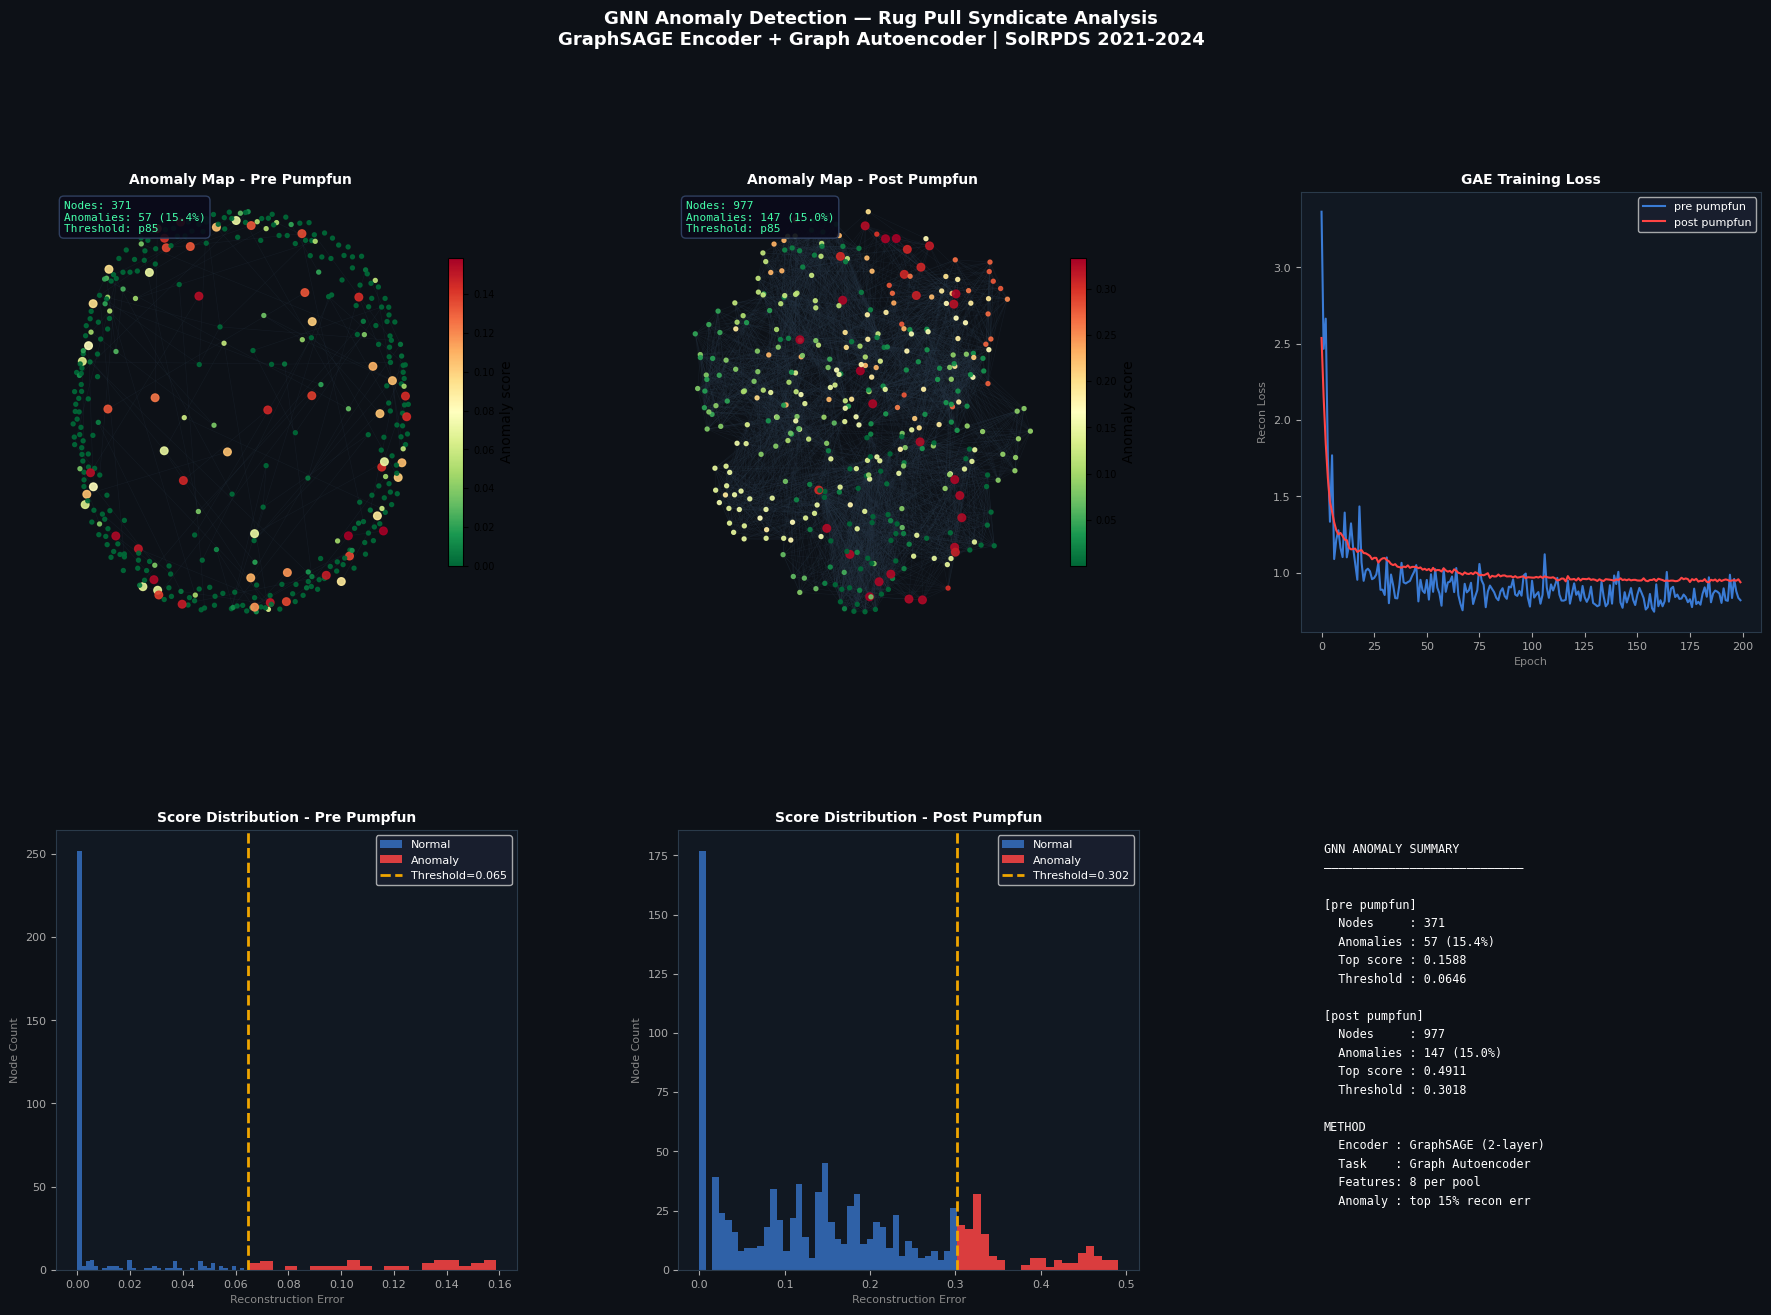

Saved: data/gold/gnn_anomaly_viz.png


In [22]:
# GNN-6: Anomaly Dashboard

panel_data = list(gnn_results.items())
fig = plt.figure(figsize=(22, 14), facecolor=BG)
gs2 = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    'GNN Anomaly Detection — Rug Pull Syndicate Analysis\n'
    'GraphSAGE Encoder + Graph Autoencoder | SolRPDS 2021-2024',
    color='white', fontsize=13, fontweight='bold', y=1.01
)

for col, (label, res) in enumerate(panel_data[:2]):
    scores  = res['anomaly_scores']
    nodes   = res['nodes']
    G_era   = res['G']
    anomaly = res['anomaly_mask']
    thresh  = res['threshold']

    ax = fig.add_subplot(gs2[0, col])
    ax_fmt(ax, f"Anomaly Map - {label.replace('_', ' ').title()}")
    if G_era.number_of_nodes() > MAX_NODES_PLOT_GNN:
        top_n  = sorted(G_era.degree(), key=lambda x: x[1], reverse=True)[:MAX_NODES_PLOT_GNN]
        G_plot = G_era.subgraph([nd for nd, _ in top_n]).copy()
        idx_m  = {p: i for i, p in enumerate(nodes)}
        pn     = [p for p in G_plot.nodes() if p in idx_m]
        ps     = np.array([scores[idx_m[p]] for p in pn])
        pa     = np.array([anomaly[idx_m[p]] for p in pn])
    else:
        G_plot, pn, ps, pa = G_era, nodes, scores, anomaly
    pos  = nx.spring_layout(G_plot, seed=42, k=0.7, iterations=50)
    norm = plt.Normalize(ps.min(), ps.max())
    nc   = [plt.cm.RdYlGn_r(norm(s)) for s in ps]
    for u, v in G_plot.edges():
        x0,y0=pos.get(u,(0,0)); x1,y1=pos.get(v,(0,0))
        ax.plot([x0,x1],[y0,y1],color='#2a3a4a',alpha=0.25,lw=0.4)
    nx.draw_networkx_nodes(G_plot, pos, ax=ax, nodelist=pn,
                           node_color=nc, node_size=[30 if a else 8 for a in pa], alpha=0.9)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.7, label='Anomaly score').ax.tick_params(labelsize=7)
    ax.text(0.02, 0.98,
            f"Nodes: {G_era.number_of_nodes():,}\nAnomalies: {anomaly.sum():,} ({anomaly.mean()*100:.1f}%)\nThreshold: p{ANOMALY_PERCENTILE}",
            transform=ax.transAxes, color=C4, fontsize=8, fontfamily='monospace', va='top',
            bbox=dict(boxstyle='round,pad=0.4', fc='#0a0a1a', ec='#334466', alpha=0.9))
    ax.axis('off')

    ax2 = fig.add_subplot(gs2[1, col])
    ax_fmt(ax2, f"Score Distribution - {label.replace('_', ' ').title()}",
           xl='Reconstruction Error', yl='Node Count')
    ax2.hist(scores[~anomaly], bins=40, color=C1, alpha=0.75, label='Normal')
    ax2.hist(scores[anomaly],  bins=20, color=C2, alpha=0.85, label='Anomaly')
    ax2.axvline(thresh, color=C3, lw=2, ls='--', label=f'Threshold={thresh:.3f}')
    ax2.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

ax = fig.add_subplot(gs2[0, 2])
ax_fmt(ax, 'GAE Training Loss', xl='Epoch', yl='Recon Loss')
for (label, res), col_c in zip(panel_data[:2], [C1, C2]):
    ax.plot(res['loss_history'], color=col_c, lw=1.5, label=label.replace('_', ' '))
ax.legend(facecolor='#1a2030', labelcolor='white', fontsize=8)

ax = fig.add_subplot(gs2[1, 2])
ax.set_facecolor('#080e18'); ax.axis('off')
lines = ['GNN ANOMALY SUMMARY', chr(8212)*28, '']
for label, res in panel_data[:2]:
    a = res['anomaly_mask']
    era_title = label.replace('_', ' ')
    lines += [f'[{era_title}]',
              f'  Nodes     : {res["G"].number_of_nodes():,}',
              f'  Anomalies : {a.sum():,} ({a.mean()*100:.1f}%)',
              f'  Top score : {res["anomaly_scores"].max():.4f}',
              f'  Threshold : {res["threshold"]:.4f}', '']
lines += ['METHOD', '  Encoder : GraphSAGE (2-layer)',
          '  Task    : Graph Autoencoder',
          '  Features: 8 per pool',
          f'  Anomaly : top {100-ANOMALY_PERCENTILE}% recon err']
ax.text(0.05, 0.97, chr(10).join(lines), transform=ax.transAxes,
        color='white', fontsize=8.5, fontfamily='monospace', va='top', linespacing=1.55)

plt.tight_layout()
plt.savefig('data/gold/gnn_anomaly_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: data/gold/gnn_anomaly_viz.png')


## MODELING & EVALUATION — Leakage-Prone Retrospective Audit

This section turns the engineered Silver table into a reproducible modeling layer. The split is created once with stratification and reused across all experiments so scores stay comparable.

Leakage controls used here:
- the supervised models fit imputers and estimators on the training fold only
- the graph-enhanced features are built from a label-free graph over raw pool relationships, not from `is_rug`
- the early-warning model is restricted to columns that look like launch/early-window signals, if those columns exist
- all result tables are exported to `data/results/`

**Interpretation constraint:** this section is retained for retrospective diagnostics only. Near-perfect supervised scores are expected when the feature matrix contains variables derived from the same lifecycle used to define `is_rug`. Do not report these results as early-prediction performance.


In [23]:
# MODEL-1: Setup, split, and reusable helpers

from IPython.display import display
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline

RESULTS_DIR = Path('data/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.25
TARGET_COL = 'is_rug'
POOL_COL = 'pool'
MINT_COL = 'mint'
TIME_COL = 'time_window'

BASE_EXCLUDE_COLS = {
    TARGET_COL,
    POOL_COL,
    MINT_COL,
    'era',
    TIME_COL,
    'FIRST',
    'LAST',
    'FIRST_POOL_ACTIVITY_TIMESTAMP',
    'LAST_POOL_ACTIVITY_TIMESTAMP',
    'LIQUIDITY_POOL_ADDRESS',
    'MINT',
    'INACTIVITY_STATUS',
}


def get_numeric_feature_columns(df: pd.DataFrame, exclude_cols=None) -> list[str]:
    exclude = set(BASE_EXCLUDE_COLS)
    if exclude_cols:
        exclude |= set(exclude_cols)
    cols = []
    for col in df.columns:
        if col in exclude:
            continue
        if pd.api.types.is_numeric_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col]):
            cols.append(col)
    return sorted(cols)


def infer_early_feature_columns(df: pd.DataFrame) -> list[str]:
    patterns = (
        'EARLY',
        'INITIAL',
        'LAUNCH',
        'EARLY_WINDOW',
        'FIRST_1H',
        'FIRST_3H',
        'FIRST_6H',
        'FIRST_12H',
        'FIRST_24H',
        'FIRST_48H',
        'FIRST_72H',
        'HOUR_1',
        'HOUR_6',
        'HOUR_24',
        'DAY_1',
        'DAY_3',
    )
    early_cols = []
    for col in get_numeric_feature_columns(df):
        upper = col.upper()
        if any(token in upper for token in patterns):
            early_cols.append(col)
    return sorted(set(early_cols))


def compute_binary_metrics(y_true, y_pred, y_score, experiment, feature_set, n_features):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    metrics_row = {
        'experiment': experiment,
        'feature_set': feature_set,
        'n_features': int(n_features),
        'test_rows': int(len(y_true)),
        'positive_rate_test': float(np.mean(y_true)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    cm_rows = pd.DataFrame(
        [
            {'experiment': experiment, 'actual': 0, 'predicted': 0, 'count': int(tn)},
            {'experiment': experiment, 'actual': 0, 'predicted': 1, 'count': int(fp)},
            {'experiment': experiment, 'actual': 1, 'predicted': 0, 'count': int(fn)},
            {'experiment': experiment, 'actual': 1, 'predicted': 1, 'count': int(tp)},
        ]
    )
    return metrics_row, cm_rows


def run_supervised_experiment(train_df, test_df, feature_cols, experiment, feature_set):
    pipe = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                RandomForestClassifier(
                    n_estimators=400,
                    min_samples_leaf=2,
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    pipe.fit(train_df[feature_cols], train_df[TARGET_COL])
    y_score = pipe.predict_proba(test_df[feature_cols])[:, 1]
    y_pred = (y_score >= 0.5).astype(int)
    metrics_row, cm_rows = compute_binary_metrics(
        test_df[TARGET_COL].to_numpy(),
        y_pred,
        y_score,
        experiment=experiment,
        feature_set=feature_set,
        n_features=len(feature_cols),
    )
    importance = pd.DataFrame(
        {
            'experiment': experiment,
            'feature_set': feature_set,
            'feature': feature_cols,
            'importance': pipe.named_steps['model'].feature_importances_,
        }
    ).sort_values('importance', ascending=False)
    predictions = test_df[[POOL_COL, TARGET_COL]].copy()
    predictions['experiment'] = experiment
    predictions['score'] = y_score
    predictions['prediction'] = y_pred
    return {
        'metrics': metrics_row,
        'confusion': cm_rows,
        'importance': importance,
        'predictions': predictions,
        'model': pipe,
    }


def run_unsupervised_experiment(train_df, test_df, feature_cols, experiment, estimator_name):
    imputer = SimpleImputer(strategy='median')
    X_train = imputer.fit_transform(train_df[feature_cols])
    X_test = imputer.transform(test_df[feature_cols])
    contamination = float(np.clip(train_df[TARGET_COL].mean(), 0.02, 0.25))

    if estimator_name == 'isolation_forest':
        detector = IsolationForest(
            n_estimators=400,
            contamination=contamination,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        detector.fit(X_train)
        train_score = -detector.score_samples(X_train)
        test_score = -detector.score_samples(X_test)
    elif estimator_name == 'lof':
        n_neighbors = int(np.clip(np.sqrt(len(train_df)), 10, 35))
        detector = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True,
        )
        detector.fit(X_train)
        train_score = -detector.decision_function(X_train)
        test_score = -detector.decision_function(X_test)
    else:
        raise ValueError(f'Unknown estimator: {estimator_name}')

    threshold = float(np.quantile(train_score, 1 - contamination))
    y_pred = (test_score >= threshold).astype(int)
    metrics_row, cm_rows = compute_binary_metrics(
        test_df[TARGET_COL].to_numpy(),
        y_pred,
        test_score,
        experiment=experiment,
        feature_set='tabular',
        n_features=len(feature_cols),
    )
    metrics_row['threshold'] = threshold
    metrics_row['contamination_train'] = contamination
    predictions = test_df[[POOL_COL, TARGET_COL]].copy()
    predictions['experiment'] = experiment
    predictions['score'] = test_score
    predictions['prediction'] = y_pred
    return {
        'metrics': metrics_row,
        'confusion': cm_rows,
        'predictions': predictions,
        'model': detector,
    }


split_df = silver.copy().sort_values('FIRST').reset_index(drop=True)
train_df, test_df = train_test_split(
    split_df,
    test_size=TEST_SIZE,
    stratify=split_df[TARGET_COL],
    random_state=RANDOM_STATE,
)
train_df = train_df.copy()
test_df = test_df.copy()

split_manifest = pd.DataFrame(
    [
        {
            'split': 'train',
            'rows': len(train_df),
            'rug_rows': int(train_df[TARGET_COL].sum()),
            'rug_rate': float(train_df[TARGET_COL].mean()),
        },
        {
            'split': 'test',
            'rows': len(test_df),
            'rug_rows': int(test_df[TARGET_COL].sum()),
            'rug_rate': float(test_df[TARGET_COL].mean()),
        },
    ]
)
split_manifest.to_csv(RESULTS_DIR / 'train_test_split_summary.csv', index=False)

experiment_metrics = []
confusion_tables = []
feature_importance_tables = []
prediction_tables = []

early_feature_cols = infer_early_feature_columns(split_df)
tabular_feature_cols = get_numeric_feature_columns(split_df)

display(split_manifest)
print(f'Tabular features available: {len(tabular_feature_cols)}')
print(f'Early-window candidates: {len(early_feature_cols)}')


,split,rows,rug_rows,rug_rate
0,train,82251,1013,0.012316
1,test,27417,338,0.012328


Tabular features available: 10
Early-window candidates: 0


### Supervised Baseline

The baseline uses the current numeric Silver features only. This is the retrospective benchmark for the notebook: same stratified split, train-only imputation, and a random forest so we get both probabilistic scores and feature importance.


In [24]:
# MODEL-2: Supervised baseline on tabular features

baseline_result = run_supervised_experiment(
    train_df=train_df,
    test_df=test_df,
    feature_cols=tabular_feature_cols,
    experiment='baseline_tabular_rf',
    feature_set='tabular',
)

experiment_metrics.append(baseline_result['metrics'])
confusion_tables.append(baseline_result['confusion'])
feature_importance_tables.append(baseline_result['importance'])
prediction_tables.append(baseline_result['predictions'])

display(pd.DataFrame([baseline_result['metrics']]))
display(baseline_result['importance'].head(15))


,experiment,feature_set,n_features,test_rows,positive_rate_test,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,baseline_tabular_rf,tabular,10,27417,0.012328,1.0,1.0,1.0,1.0,1.0,27079,0,0,338


,experiment,feature_set,feature,importance
6,baseline_tabular_rf,tabular,burst_window_size,0.471578
0,baseline_tabular_rf,tabular,ADD_TO_REMOVE_RATIO,0.228433
8,baseline_tabular_rf,tabular,lifespan_min,0.154473
9,baseline_tabular_rf,tabular,lifespan_velocity,0.085581
3,baseline_tabular_rf,tabular,TOTAL_ADDED_LIQUIDITY,0.023001
7,baseline_tabular_rf,tabular,is_burst,0.022525
1,baseline_tabular_rf,tabular,NUM_LIQUIDITY_ADDS,0.007615
4,baseline_tabular_rf,tabular,TOTAL_REMOVED_LIQUIDITY,0.003618
2,baseline_tabular_rf,tabular,NUM_LIQUIDITY_REMOVES,0.003176
5,baseline_tabular_rf,tabular,_has_creator_wallet,0.000000


### Graph Feature Extraction

The original graph analysis above is rug-focused, which is useful for community diagnostics but would leak target information into a predictive model. For modeling, this section rebuilds a label-free NetworkX graph from the same pool relationships (`mint` overlap and synchronized activity windows), then derives node-level structural features for every pool.


In [26]:
# MODEL-3: Build a label-free modeling graph and extract FAST node features
# This version avoids MemoryError and long runtimes by:
# 1. capping edges per mint/time group
# 2. removing expensive betweenness centrality
# 3. using faster PageRank settings
# 4. skipping community detection on very large graphs

from itertools import combinations
from collections import Counter
import random
import time

MAX_GROUP_SIZE = 150
MAX_EDGES_PER_GROUP = 3000
MAX_COMMUNITY_NODES = 10000
MAX_COMMUNITY_EDGES = 100000


def add_limited_edges(G, pools, weight, edge_type):
    pools = [p for p in pools if pd.notna(p)]
    pools = list(dict.fromkeys(pools))

    if len(pools) < 2:
        return

    if len(pools) > MAX_GROUP_SIZE:
        random.seed(RANDOM_STATE)
        pools = random.sample(pools, MAX_GROUP_SIZE)

    pairs = list(combinations(pools, 2))

    if len(pairs) > MAX_EDGES_PER_GROUP:
        random.seed(RANDOM_STATE)
        pairs = random.sample(pairs, MAX_EDGES_PER_GROUP)

    for u, v in pairs:
        if G.has_edge(u, v):
            G[u][v]["weight"] += weight
            G[u][v][edge_type] = True
        else:
            G.add_edge(
                u,
                v,
                weight=weight,
                shared_mint=edge_type == "shared_mint",
                time_window=edge_type == "time_window",
            )


def build_modeling_graph(df: pd.DataFrame) -> nx.Graph:
    graph_df = df[[POOL_COL, MINT_COL, TIME_COL]].dropna(subset=[POOL_COL]).copy()

    G = nx.Graph()
    G.add_nodes_from(graph_df[POOL_COL].dropna().unique())

    for mint, pools in graph_df.groupby(MINT_COL)[POOL_COL].unique().items():
        add_limited_edges(
            G,
            pools,
            weight=WEIGHT_SHARED_MINT,
            edge_type="shared_mint",
        )

    for win, pools in graph_df.groupby(TIME_COL)[POOL_COL].unique().items():
        add_limited_edges(
            G,
            pools,
            weight=WEIGHT_TIME_WINDOW,
            edge_type="time_window",
        )

    return G


def detect_modeling_partition_fast(G: nx.Graph) -> dict:
    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        return {}

    if (
        G.number_of_nodes() > MAX_COMMUNITY_NODES
        or G.number_of_edges() > MAX_COMMUNITY_EDGES
    ):
        print("Skipping community detection because graph is large.")
        return {}

    if HAS_LOUVAIN:
        return community_louvain.best_partition(
            G,
            weight="weight",
            random_state=RANDOM_STATE,
        )

    from networkx.algorithms.community import greedy_modularity_communities

    communities = list(greedy_modularity_communities(G, weight="weight"))
    return {node: cid for cid, members in enumerate(communities) for node in members}


def extract_graph_features_fast(df: pd.DataFrame, G: nx.Graph) -> pd.DataFrame:
    unique_pools = df[POOL_COL].dropna().drop_duplicates()

    if G.number_of_nodes() == 0:
        return pd.DataFrame({POOL_COL: unique_pools})

    degree = dict(G.degree())
    weighted_degree = dict(G.degree(weight="weight"))

    clustering = (
        nx.clustering(G)
        if G.number_of_edges()
        else {n: 0.0 for n in G.nodes()}
    )

    if G.number_of_edges():
        pagerank = nx.pagerank(
            G,
            weight="weight",
            max_iter=50,
            tol=1e-4,
        )
    else:
        pagerank = {n: 0.0 for n in G.nodes()}

    component_size = {}
    for members in nx.connected_components(G):
        size = len(members)
        for node in members:
            component_size[node] = size

    partition = detect_modeling_partition_fast(G)
    community_sizes = Counter(partition.values()) if partition else Counter()

    rows = []

    for pool in unique_pools:
        community_id = partition.get(pool, None)

        rows.append(
            {
                POOL_COL: pool,
                "graph_degree": float(degree.get(pool, 0.0)),
                "graph_weighted_degree": float(weighted_degree.get(pool, 0.0)),
                "graph_clustering": float(clustering.get(pool, 0.0)),
                "graph_pagerank": float(pagerank.get(pool, 0.0)),
                "graph_component_size": float(
                    component_size.get(pool, 1.0 if pool in G else 0.0)
                ),
                "graph_community_id": float(community_id)
                if community_id is not None
                else -1.0,
                "graph_community_size": float(
                    community_sizes.get(
                        community_id,
                        1.0 if pool in G else 0.0,
                    )
                ),
                "graph_is_isolate": float(degree.get(pool, 0.0) == 0.0),
            }
        )

    return pd.DataFrame(rows)


start = time.time()
modeling_graph = build_modeling_graph(split_df)

print(
    f"Graph built in {time.time() - start:.2f}s | "
    f"nodes={modeling_graph.number_of_nodes():,}, "
    f"edges={modeling_graph.number_of_edges():,}"
)

start = time.time()
graph_feature_df = extract_graph_features_fast(split_df, modeling_graph)

print(f"Graph features extracted in {time.time() - start:.2f}s")

graph_feature_df.to_csv(RESULTS_DIR / "graph_node_features.csv", index=False)

modeling_with_graph = split_df.merge(graph_feature_df, on=POOL_COL, how="left")
graph_feature_cols = [col for col in graph_feature_df.columns if col != POOL_COL]

display(graph_feature_df.head())

print(
    f"Modeling graph: nodes={modeling_graph.number_of_nodes():,} "
    f"edges={modeling_graph.number_of_edges():,} "
    f"graph features={len(graph_feature_cols)}"
)

Graph built in 11.60s | nodes=63,520, edges=1,801,958
Skipping community detection because graph is large.
Graph features extracted in 48.63s


,pool,graph_degree,graph_weighted_degree,graph_clustering,graph_pagerank,graph_component_size,graph_community_id,graph_community_size,graph_is_isolate
0,4vWJYxLx9F7WPQeeYzg9cxhDeaPjwruZXCffaSknWFxy,18.0,37.0,0.830065,0.000014,61990.0,-1.0,1.0,0.0
1,DY8qBwVGLeLJSrWib7L16mL7oB4HNAQ2f9yiYWKof54v,18.0,37.0,0.830065,0.000014,61990.0,-1.0,1.0,0.0
2,GTy6wKTohJUNyL2DPozFqQnmW132oAemPQejXmCQusSR,20.0,43.0,0.694737,0.000021,61990.0,-1.0,1.0,0.0
3,Fz6yRGsNiXK7hVu4D2zvbwNXW8FQvyJ5edacs3piR1P7,40.0,83.0,0.496154,0.000021,61990.0,-1.0,1.0,0.0
4,6fTRDD7sYxCN7oyoSQaN1AWC3P2m8A6gVZzGrpej9DvL,5.0,5.0,1.000000,0.000005,61990.0,-1.0,1.0,0.0


Modeling graph: nodes=63,520 edges=1,801,958 graph features=8


### Graph-Enhanced Classifier

This experiment augments the baseline feature matrix with node-level graph features. The graph itself is label-free; only the classifier sees the rug labels during training.


In [27]:
# MODEL-4: Graph-enhanced supervised classifier

train_graph_df = modeling_with_graph.loc[train_df.index].copy()
test_graph_df = modeling_with_graph.loc[test_df.index].copy()
graph_enhanced_feature_cols = sorted(set(tabular_feature_cols + graph_feature_cols))

graph_result = run_supervised_experiment(
    train_df=train_graph_df,
    test_df=test_graph_df,
    feature_cols=graph_enhanced_feature_cols,
    experiment='graph_enhanced_rf',
    feature_set='tabular_plus_graph',
)

experiment_metrics.append(graph_result['metrics'])
confusion_tables.append(graph_result['confusion'])
feature_importance_tables.append(graph_result['importance'])
prediction_tables.append(graph_result['predictions'])

display(pd.DataFrame([graph_result['metrics']]))
display(graph_result['importance'].head(15))


,experiment,feature_set,n_features,test_rows,positive_rate_test,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,graph_enhanced_rf,tabular_plus_graph,18,27417,0.012328,1.0,1.0,1.0,1.0,1.0,27079,0,0,338


,experiment,feature_set,feature,importance
6,graph_enhanced_rf,tabular_plus_graph,burst_window_size,4.080193e-01
0,graph_enhanced_rf,tabular_plus_graph,ADD_TO_REMOVE_RATIO,2.628133e-01
16,graph_enhanced_rf,tabular_plus_graph,lifespan_min,1.362594e-01
17,graph_enhanced_rf,tabular_plus_graph,lifespan_velocity,9.520579e-02
3,graph_enhanced_rf,tabular_plus_graph,TOTAL_ADDED_LIQUIDITY,3.047946e-02
15,graph_enhanced_rf,tabular_plus_graph,is_burst,2.318286e-02
1,graph_enhanced_rf,tabular_plus_graph,NUM_LIQUIDITY_ADDS,1.372700e-02
4,graph_enhanced_rf,tabular_plus_graph,TOTAL_REMOVED_LIQUIDITY,1.130462e-02
2,graph_enhanced_rf,tabular_plus_graph,NUM_LIQUIDITY_REMOVES,8.196830e-03
14,graph_enhanced_rf,tabular_plus_graph,graph_weighted_degree,6.301726e-03


### Unsupervised Anomaly Detection

The anomaly module is evaluated on the same holdout fold, but the detectors themselves are fit without labels. A train-derived contamination level is used only to convert continuous anomaly scores into binary flags for the confusion matrix; ROC-AUC and PR-AUC are computed from the raw scores.

In [28]:
# MODEL-5: Isolation Forest and Local Outlier Factor

iforest_result = run_unsupervised_experiment(
    train_df=train_df,
    test_df=test_df,
    feature_cols=tabular_feature_cols,
    experiment='isolation_forest',
    estimator_name='isolation_forest',
)
lof_result = run_unsupervised_experiment(
    train_df=train_df,
    test_df=test_df,
    feature_cols=tabular_feature_cols,
    experiment='local_outlier_factor',
    estimator_name='lof',
)

for result in [iforest_result, lof_result]:
    experiment_metrics.append(result['metrics'])
    confusion_tables.append(result['confusion'])
    prediction_tables.append(result['predictions'])

display(pd.DataFrame([iforest_result['metrics'], lof_result['metrics']]))


,experiment,feature_set,n_features,test_rows,positive_rate_test,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold,contamination_train
0,isolation_forest,tabular,10,27417,0.012328,0.242373,0.423077,0.308190,0.962578,0.176691,26632,447,195,143,0.564956,0.02
1,local_outlier_factor,tabular,10,27417,0.012328,0.003241,0.005917,0.004188,0.520256,0.012072,26464,615,336,2,-0.041836,0.02


### Early-Warning Model

If the Silver table already contains launch-window or early-window numeric features, this section trains a dedicated classifier using only those fields. If those columns are not present yet, the notebook records that explicitly and leaves the experiment out of the comparison table rather than silently failing.

In [29]:
# MODEL-6: Early-warning classifier when early-window features exist

early_warning_status = pd.DataFrame(
    [{'status': 'skipped', 'reason': 'No early-window features detected', 'feature_count': 0}]
)

if early_feature_cols:
    early_result = run_supervised_experiment(
        train_df=train_df,
        test_df=test_df,
        feature_cols=early_feature_cols,
        experiment='early_warning_rf',
        feature_set='early_window_only',
    )
    experiment_metrics.append(early_result['metrics'])
    confusion_tables.append(early_result['confusion'])
    feature_importance_tables.append(early_result['importance'])
    prediction_tables.append(early_result['predictions'])
    early_warning_status = pd.DataFrame(
        [{'status': 'trained', 'reason': 'Early-window features detected', 'feature_count': len(early_feature_cols)}]
    )
    display(pd.DataFrame([early_result['metrics']]))
    display(early_result['importance'].head(15))
else:
    print('No early-window feature columns detected. Skipping dedicated early-warning model.')

early_warning_status.to_csv(RESULTS_DIR / 'early_warning_status.csv', index=False)
display(early_warning_status)

No early-window feature columns detected. Skipping dedicated early-warning model.


,status,reason,feature_count
0,skipped,No early-window features detected,0


### Experiment Comparison And Export

This final section consolidates confusion matrices, scalar metrics, feature importance, and test-set predictions into flat result tables under `data/results/` so the experiments can be compared outside the notebook as well.

In [30]:
# MODEL-7: Save comparison tables and show final leaderboard

metrics_df = pd.DataFrame(experiment_metrics).sort_values(
    ['pr_auc', 'roc_auc', 'f1'],
    ascending=False,
).reset_index(drop=True)
confusion_df = pd.concat(confusion_tables, ignore_index=True)
predictions_df = pd.concat(prediction_tables, ignore_index=True)
importance_df = (
    pd.concat(feature_importance_tables, ignore_index=True)
    if feature_importance_tables else
    pd.DataFrame(columns=['experiment', 'feature_set', 'feature', 'importance'])
)

metrics_df.to_csv(RESULTS_DIR / 'experiment_comparison.csv', index=False)
confusion_df.to_csv(RESULTS_DIR / 'confusion_matrices.csv', index=False)
predictions_df.to_csv(RESULTS_DIR / 'test_set_predictions.csv', index=False)
importance_df.to_csv(RESULTS_DIR / 'feature_importance.csv', index=False)

display(metrics_df)
display(confusion_df)
display(importance_df.groupby('experiment').head(10))

print('Saved:')
print(f'  - {RESULTS_DIR / "train_test_split_summary.csv"}')
print(f'  - {RESULTS_DIR / "graph_node_features.csv"}')
print(f'  - {RESULTS_DIR / "experiment_comparison.csv"}')
print(f'  - {RESULTS_DIR / "confusion_matrices.csv"}')
print(f'  - {RESULTS_DIR / "feature_importance.csv"}')
print(f'  - {RESULTS_DIR / "test_set_predictions.csv"}')
print(f'  - {RESULTS_DIR / "early_warning_status.csv"}')


,experiment,feature_set,n_features,test_rows,positive_rate_test,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,threshold,contamination_train
0,baseline_tabular_rf,tabular,10,27417,0.012328,1.000000,1.000000,1.000000,1.000000,1.000000,27079,0,0,338,NaN,NaN
1,graph_enhanced_rf,tabular_plus_graph,18,27417,0.012328,1.000000,1.000000,1.000000,1.000000,1.000000,27079,0,0,338,NaN,NaN
2,isolation_forest,tabular,10,27417,0.012328,0.242373,0.423077,0.308190,0.962578,0.176691,26632,447,195,143,0.564956,0.02
3,local_outlier_factor,tabular,10,27417,0.012328,0.003241,0.005917,0.004188,0.520256,0.012072,26464,615,336,2,-0.041836,0.02


,experiment,actual,predicted,count
0,baseline_tabular_rf,0,0,27079
1,baseline_tabular_rf,0,1,0
2,baseline_tabular_rf,1,0,0
3,baseline_tabular_rf,1,1,338
4,graph_enhanced_rf,0,0,27079
5,graph_enhanced_rf,0,1,0
6,graph_enhanced_rf,1,0,0
7,graph_enhanced_rf,1,1,338
8,isolation_forest,0,0,26632
9,isolation_forest,0,1,447


,experiment,feature_set,feature,importance
0,baseline_tabular_rf,tabular,burst_window_size,0.471578
1,baseline_tabular_rf,tabular,ADD_TO_REMOVE_RATIO,0.228433
2,baseline_tabular_rf,tabular,lifespan_min,0.154473
3,baseline_tabular_rf,tabular,lifespan_velocity,0.085581
4,baseline_tabular_rf,tabular,TOTAL_ADDED_LIQUIDITY,0.023001
5,baseline_tabular_rf,tabular,is_burst,0.022525
6,baseline_tabular_rf,tabular,NUM_LIQUIDITY_ADDS,0.007615
7,baseline_tabular_rf,tabular,TOTAL_REMOVED_LIQUIDITY,0.003618
8,baseline_tabular_rf,tabular,NUM_LIQUIDITY_REMOVES,0.003176
9,baseline_tabular_rf,tabular,_has_creator_wallet,0.000000


Saved:
  - data\results\train_test_split_summary.csv
  - data\results\graph_node_features.csv
  - data\results\experiment_comparison.csv
  - data\results\confusion_matrices.csv
  - data\results\feature_importance.csv
  - data\results\test_set_predictions.csv
  - data\results\early_warning_status.csv
